In [1]:
import geopandas as gpd
import osmnx as ox
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt

print("Окэй")

Окэй


In [2]:
from shapely.geometry import box

def build_grid(border, cell_size=1000):
    minx, miny, maxx, maxy = border.total_bounds
    minx = np.floor(minx / cell_size) * cell_size
    miny = np.floor(miny / cell_size) * cell_size
    maxx = np.ceil(maxx / cell_size) * cell_size
    maxy = np.ceil(maxy / cell_size) * cell_size

    cells = []
    for x in np.arange(minx, maxx, cell_size):
        for y in np.arange(miny, maxy, cell_size):
            cells.append(box(x, y, x + cell_size, y + cell_size))

    grid = gpd.GeoDataFrame({'geometry': cells}, crs=border.crs)
    grid = gpd.overlay(grid, border[['geometry']], how='intersection')
    grid['cell_id'] = range(len(grid))
    grid['area_km2'] = grid.geometry.area / 1e6
    return grid

Скачана граница Московской области
Площадь: 139,416 км²


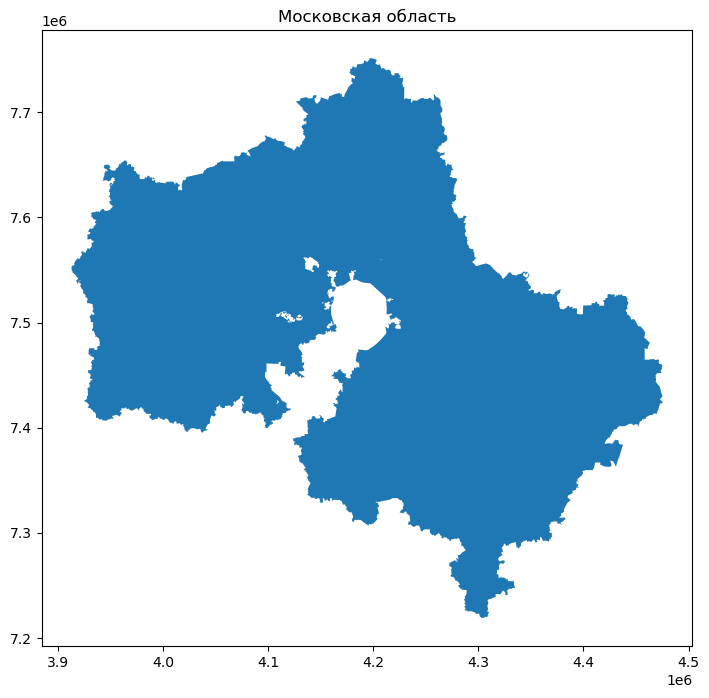

In [3]:
mo = ox.geocode_to_gdf("Moscow Oblast, Russia")
mo = mo.to_crs(epsg=3857)
mo.to_file("../data/processed/border_mo.gpkg", driver="GPKG")

area_km2 = mo.geometry.area.sum() / 1e6
print(f"Скачана граница Московской области")
print(f"Площадь: {area_km2:,.0f} км²")

mo.plot(figsize=(10, 8))
plt.title("Московская область")
plt.show()

In [4]:
import os
os.makedirs("../data/processed", exist_ok=True)
print("создалась")

создалась


In [5]:
if os.path.exists("../data/processed/grid_mo.gpkg"):
    grid_mo = gpd.read_file("../data/processed/grid_mo.gpkg")
    print(f"Сетка MO загружена с диска: {len(grid_mo):,} ячеек")
else:
    grid_mo = build_grid(mo)
    grid_mo.to_file("../data/processed/grid_mo.gpkg", driver="GPKG")
    print(f"Сетка MO построена и сохранена: {len(grid_mo):,} ячеек")

Сетка MO загружена с диска: 141,967 ячеек


In [6]:
print(f"Всего ячеек: {len(grid_mo):,}")
print(f"Средняя площадь ячейки: {grid_mo['area_km2'].mean():.3f} км²")
print(f"Самая маленькая ячейка: {grid_mo['area_km2'].min():.3f} км²")
print(f"Самая большая ячейка: {grid_mo['area_km2'].max():.3f} км²")
print(f"Суммарная площадь: {grid_mo['area_km2'].sum():,.0f} км²")

Всего ячеек: 141,967
Средняя площадь ячейки: 0.982 км²
Самая маленькая ячейка: 0.000 км²
Самая большая ячейка: 1.000 км²
Суммарная площадь: 139,416 км²


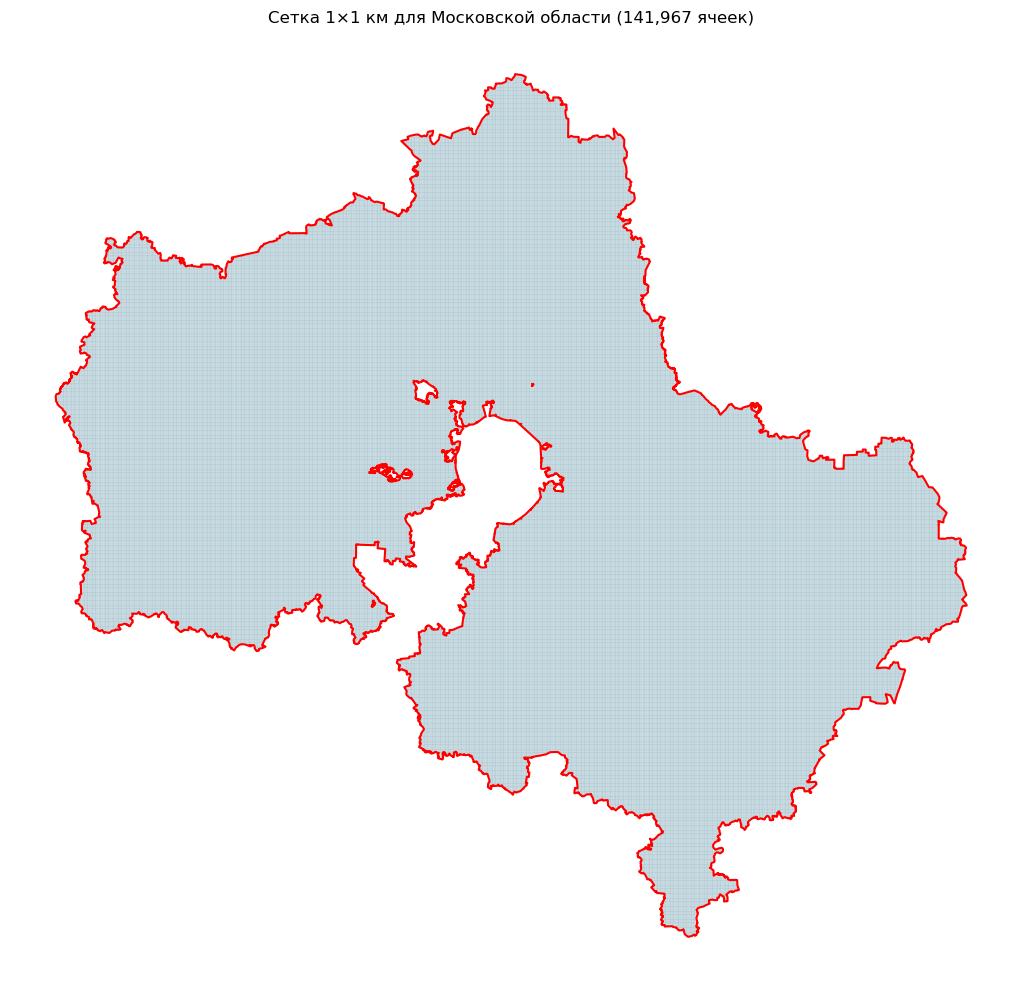

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))

mo.boundary.plot(ax=ax, color='red', linewidth=1.5)

grid_mo.plot(ax=ax, edgecolor='black', linewidth=0.05, facecolor='lightblue', alpha=0.5)

ax.set_title(f"Сетка 1×1 км для Московской области ({len(grid_mo):,} ячеек)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [8]:
from shapely.geometry import Point

cities_wgs84 = {
    'Москва': (37.6173, 55.7558),
    'Балашиха': (37.9384, 55.7964),
    'Подольск': (37.5447, 55.4297),
    'Химки': (37.4448, 55.8970),
    'Мытищи': (37.7295, 55.9117),
    'Люберцы': (37.9534, 55.6760),
    'Электросталь': (38.4445, 55.7847),
    'Коломна': (38.7544, 55.0794),
    'Серпухов': (37.4216, 54.9156),
}

cities_gdf = gpd.GeoDataFrame(
    {'city': list(cities_wgs84.keys())},
    geometry=[Point(lon, lat) for lon, lat in cities_wgs84.values()],
    crs='EPSG:4326'
).to_crs(epsg=3857)

print(f"Города загружены: {len(cities_gdf)}")
cities_gdf

Города загружены: 9


,city,geometry
0,Москва,POINT (4187538.681 7509955.142)
1,Балашиха,POINT (4223283.37 7517990.961)
2,Подольск,POINT (4179456.886 7445712.741)
3,Химки,POINT (4168336.069 7537938.534)
4,Мытищи,POINT (4200028.728 7540857.667)
5,Люберцы,POINT (4224953.162 7494184.949)
6,Электросталь,POINT (4279622.164 7515674.361)
7,Коломна,POINT (4314120.074 7377291.308)
8,Серпухов,POINT (4165753.457 7345502.994)


In [9]:
grid_mo['centroid'] = grid_mo.geometry.centroid

print(f"Центроидов: {len(grid_mo)}")
grid_mo[['cell_id', 'area_km2', 'centroid']].head()

Центроидов: 141967


,cell_id,area_km2,centroid
0,0,0.058086,POINT (3912888.345 7549882.916)
1,1,0.076979,POINT (3912939.842 7550373.068)
2,2,0.116458,POINT (3912939.358 7551558.765)
3,3,0.179033,POINT (3912908.626 7552494.021)
4,4,0.013256,POINT (3912965.773 7553086.066)


In [10]:
moscow_point = cities_gdf[cities_gdf['city'] == 'Москва'].geometry.iloc[0]
grid_mo['dist_to_moscow_km'] = grid_mo['centroid'].distance(moscow_point) / 1000

print(f"Расстояние до Москвы:")
print(f"  Минимум: {grid_mo['dist_to_moscow_km'].min():.1f} км")
print(f"  Максимум: {grid_mo['dist_to_moscow_km'].max():.1f} км")
print(f"  Среднее: {grid_mo['dist_to_moscow_km'].mean():.1f} км")

Расстояние до Москвы:
  Минимум: 25.3 км
  Максимум: 314.2 км
  Среднее: 163.3 км


In [11]:
def min_distance_to_cities(point, cities):
    return min(point.distance(c) for c in cities.geometry)

grid_mo['dist_to_city_km'] = grid_mo['centroid'].apply(
    lambda p: min_distance_to_cities(p, cities_gdf) / 1000
)

print(f"Расстояние до ближайшего города:")
print(f"  Минимум: {grid_mo['dist_to_city_km'].min():.1f} км")
print(f"  Максимум: {grid_mo['dist_to_city_km'].max():.1f} км")
print(f"  Среднее: {grid_mo['dist_to_city_km'].mean():.1f} км")

Расстояние до ближайшего города:
  Минимум: 0.2 км
  Максимум: 255.8 км
  Среднее: 99.4 км


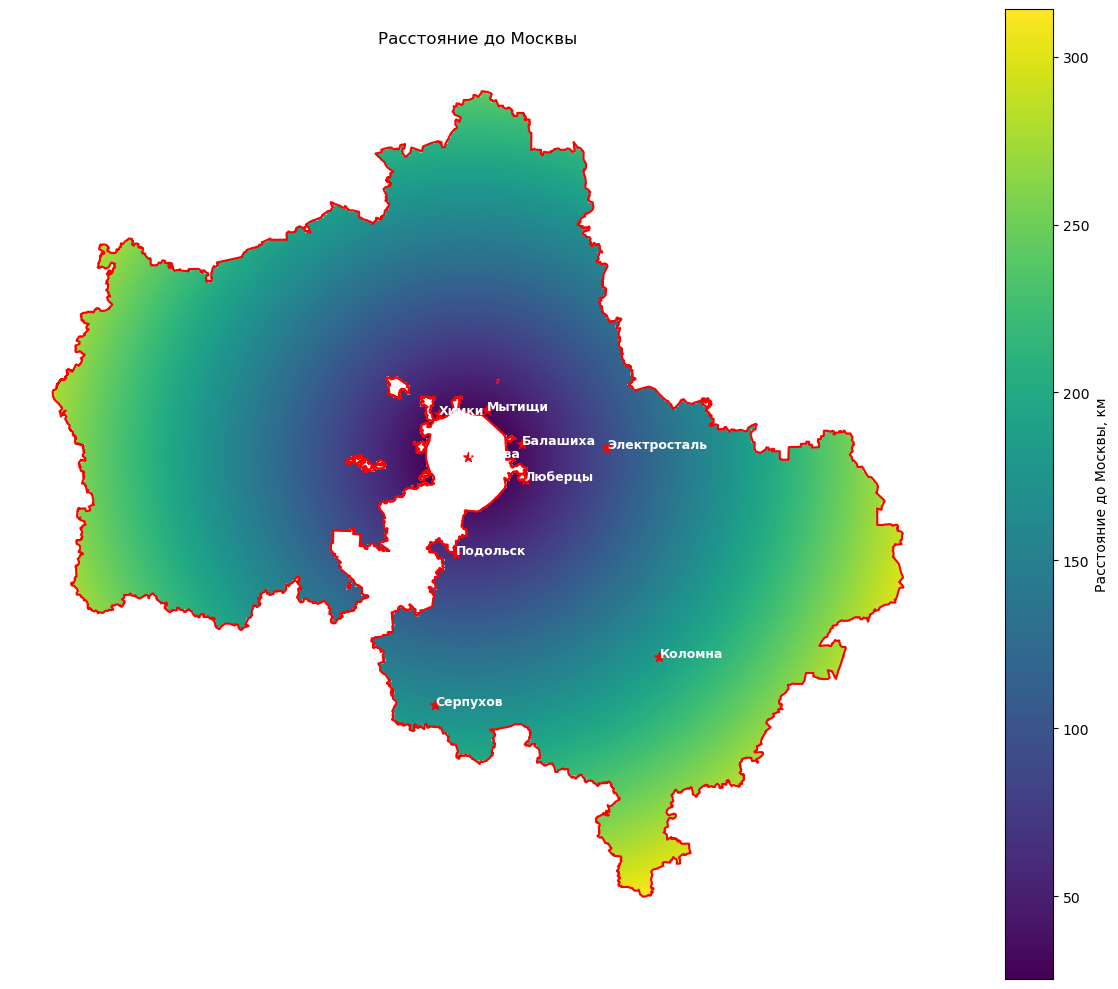

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

grid_mo.plot(column='dist_to_moscow_km', ax=ax, cmap='viridis', 
             legend=True, legend_kwds={'label': 'Расстояние до Москвы, км'})

cities_gdf.plot(ax=ax, color='red', markersize=50, marker='*')
for idx, row in cities_gdf.iterrows():
    ax.annotate(row['city'], (row.geometry.x, row.geometry.y), 
                fontsize=9, color='white', weight='bold')

mo.boundary.plot(ax=ax, color='red', linewidth=1.5)

ax.set_title("Расстояние до Москвы")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [13]:
grid_mo['city_weight'] = 1 / (grid_mo['dist_to_city_km'] + 1)
grid_mo['moscow_weight'] = 1 / (grid_mo['dist_to_moscow_km'] + 1)
print(grid_mo[['city_weight', 'moscow_weight']].describe())

         city_weight  moscow_weight
count  141967.000000  141967.000000
mean        0.017873       0.007504
std         0.024464       0.004440
min         0.003893       0.003172
25%         0.006938       0.004705
50%         0.011327       0.006080
75%         0.019366       0.008530
max         0.824471       0.038046


In [14]:
# Региональное значение отгрузки для Моск области
X_region_otgr = 209.0  # млрд руб

# BASELINE
grid_mo['baseline_otgr'] = X_region_otgr * grid_mo['area_km2'] / grid_mo['area_km2'].sum()

print(f"BASELINE для отгрузки:")
print(f"  Сумма: {grid_mo['baseline_otgr'].sum():.2f} млрд руб")
print(f"  Минимум: {grid_mo['baseline_otgr'].min():.6f}")
print(f"  Максимум: {grid_mo['baseline_otgr'].max():.6f}")
print(f"  Все ячейки получают примерно одинаковое значение. это и есть baseline")

BASELINE для отгрузки:
  Сумма: 209.00 млрд руб
  Минимум: 0.000000
  Максимум: 0.001499
  Все ячейки получают примерно одинаковое значение. это и есть baseline


In [15]:
# вес ячейки = комбинация близости к Москве и близости к городам
grid_mo['weight'] = (
    0.7 * grid_mo['moscow_weight'] + 
    0.3 * grid_mo['city_weight']
)

grid_mo['method_otgr'] = X_region_otgr * grid_mo['weight'] / grid_mo['weight'].sum()

print(f"МЕТОД для отгрузки:")
print(f"  Сумма: {grid_mo['method_otgr'].sum():.2f} млрд руб")
print(f"  Минимум: {grid_mo['method_otgr'].min():.6f}")
print(f"  Максимум: {grid_mo['method_otgr'].max():.6f}")
print(f"  Разница макс/мин: {grid_mo['method_otgr'].max() / grid_mo['method_otgr'].min():.0f}x")

МЕТОД для отгрузки:
  Сумма: 209.00 млрд руб
  Минимум: 0.000510
  Максимум: 0.035658
  Разница макс/мин: 70x


In [16]:
import os
os.makedirs("../results", exist_ok=True)
print("создана")

создана


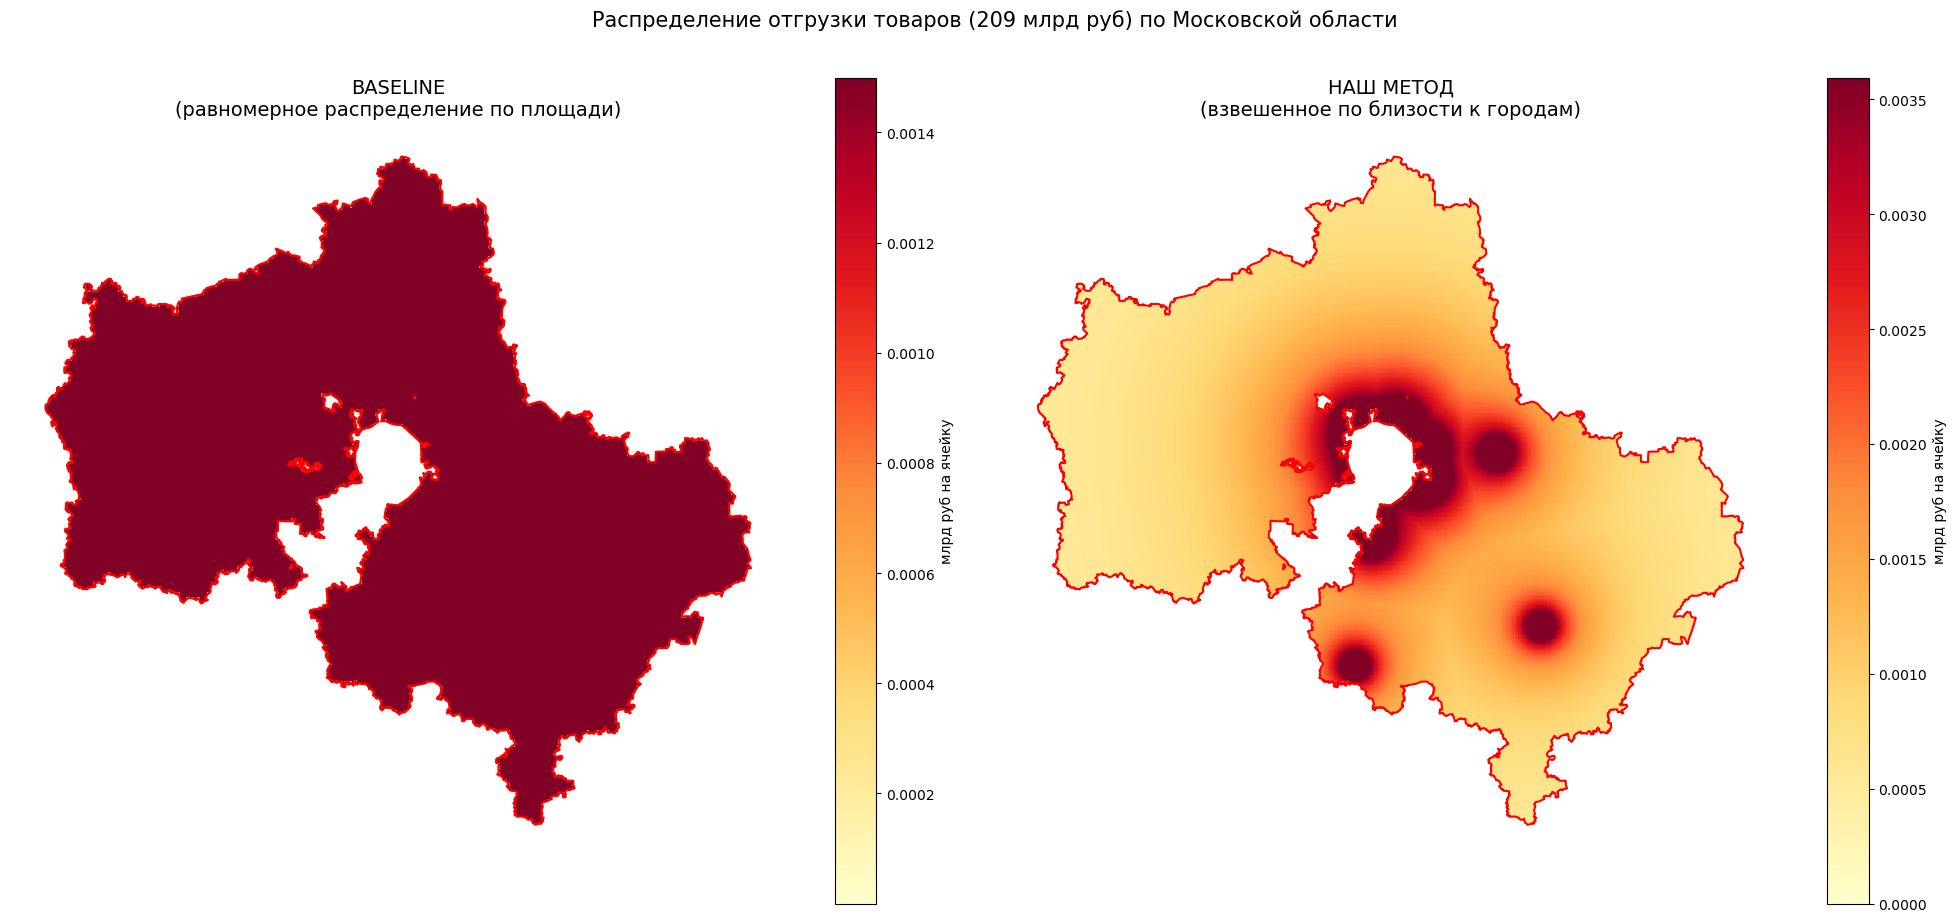

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# BASELINE
grid_mo.plot(column='baseline_otgr', ax=axes[0], cmap='YlOrRd', legend=True,
             legend_kwds={'label': 'млрд руб на ячейку'})
mo.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE\n(равномерное распределение по площади)', fontsize=14)
axes[0].set_axis_off()

# НАШ МЕТОД - используем log-цветовую шкалу через vmax (отрезаем верхние выбросы)
import numpy as np
vmax = grid_mo['method_otgr'].quantile(0.95)  

grid_mo.plot(column='method_otgr', ax=axes[1], cmap='YlOrRd', legend=True,
             vmin=0, vmax=vmax,
             legend_kwds={'label': 'млрд руб на ячейку'})
mo.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД\n(взвешенное по близости к городам)', fontsize=14)
axes[1].set_axis_off()

plt.suptitle('Распределение отгрузки товаров (209 млрд руб) по Московской области', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import numpy as np

def gini(values):
    sorted_v = np.sort(values)
    n = len(values)
    cumsum = np.cumsum(sorted_v)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

print("=== Сравнение с baseline ===\n")

print(f"Сумма baseline: {grid_mo['baseline_otgr'].sum():.2f}")
print(f"Сумма метода:   {grid_mo['method_otgr'].sum():.2f}")
print(f"Ожидаемое:      209.0\n")

gini_b = gini(grid_mo['baseline_otgr'].values)
gini_m = gini(grid_mo['method_otgr'].values)
print(f"Джини baseline: {gini_b:.4f}")
print(f"Джини метода:   {gini_m:.4f}\n")

top10_pct = int(len(grid_mo) * 0.1)
top10_b = grid_mo['baseline_otgr'].nlargest(top10_pct).sum() / grid_mo['baseline_otgr'].sum()
top10_m = grid_mo['method_otgr'].nlargest(top10_pct).sum() / grid_mo['method_otgr'].sum()
print(f"Доля в топ-10% ячеек:")
print(f"  Baseline: {top10_b:.1%}")
print(f"  Метод:    {top10_m:.1%}")

=== Сравнение с baseline ===

Сумма baseline: 209.00
Сумма метода:   209.00
Ожидаемое:      209.0

Джини baseline: 0.0179
Джини метода:   0.3487

Доля в топ-10% ячеек:
  Baseline: 10.2%
  Метод:    29.5%


In [19]:
X_region_shx = 85692.0  # млн руб

grid_mo['baseline_shx'] = X_region_shx * grid_mo['area_km2'] / grid_mo['area_km2'].sum()

grid_mo['shx_weight'] = grid_mo['dist_to_city_km'] / (grid_mo['dist_to_moscow_km'] + 1)

grid_mo['method_shx'] = X_region_shx * grid_mo['shx_weight'] / grid_mo['shx_weight'].sum()

print(f"Сумма baseline: {grid_mo['baseline_shx'].sum():.2f}")
print(f"Сумма метода:   {grid_mo['method_shx'].sum():.2f}")
print(f"Ожидаемое:      85692.0")

Сумма baseline: 85692.00
Сумма метода:   85692.00
Ожидаемое:      85692.0


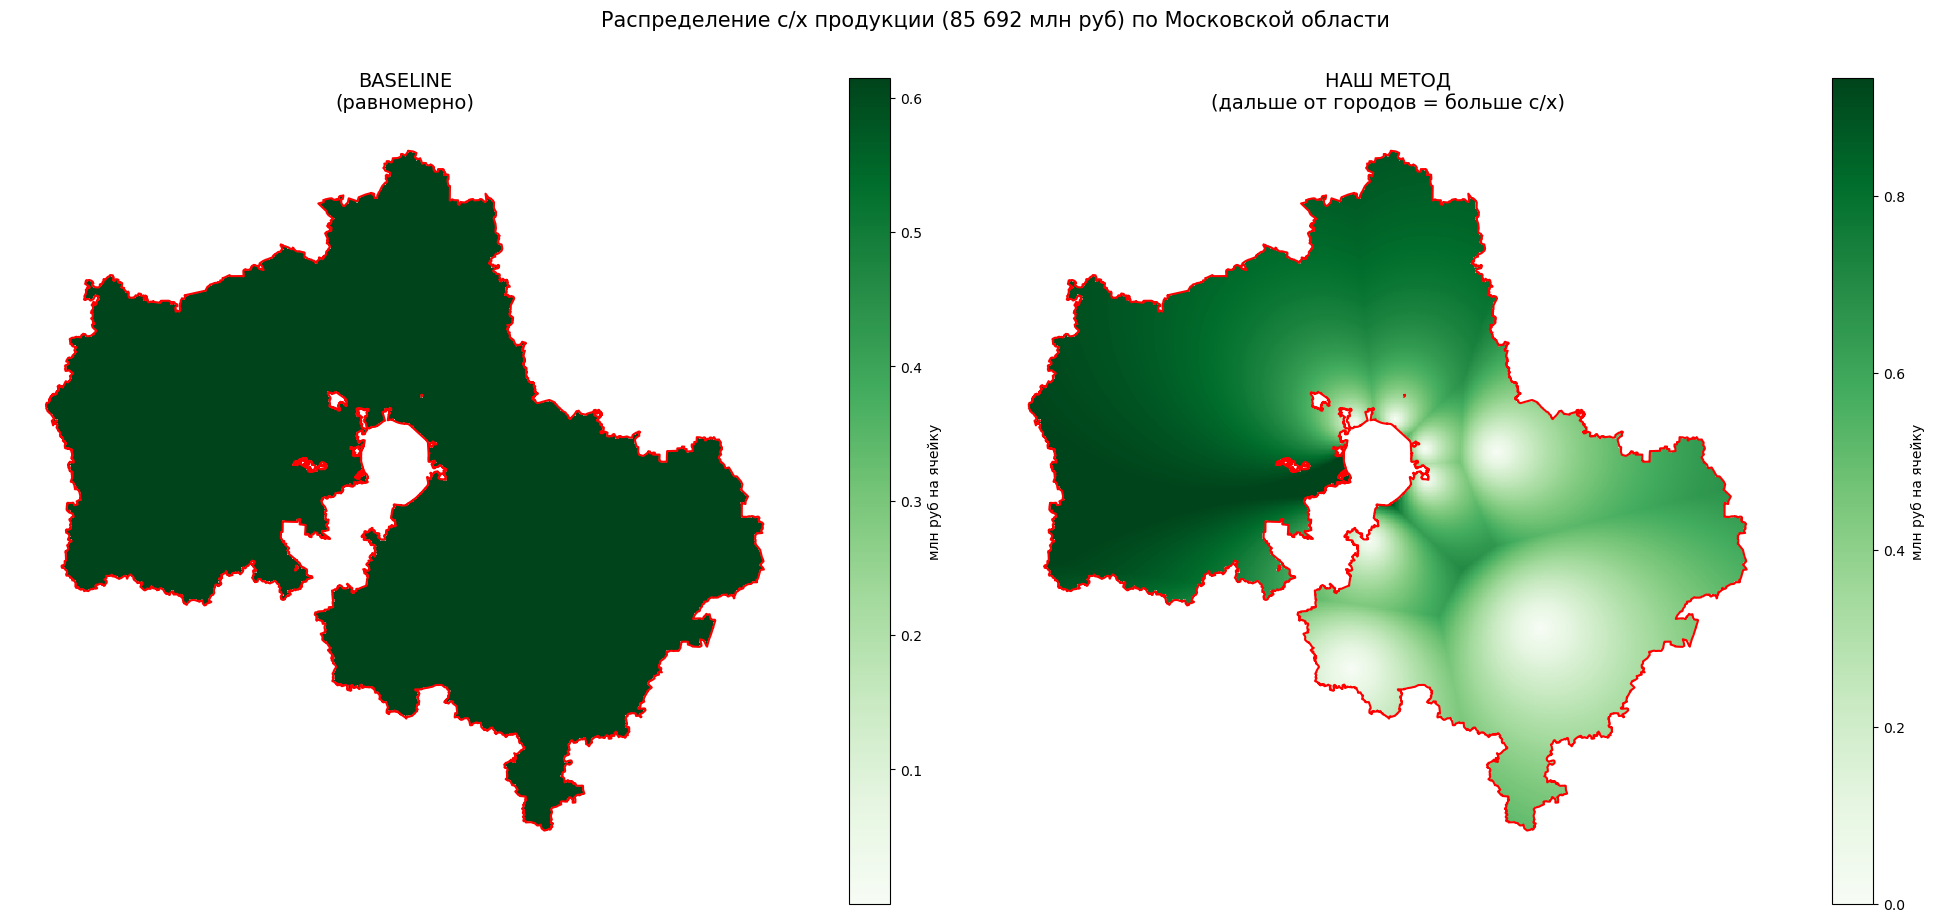

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

grid_mo.plot(column='baseline_shx', ax=axes[0], cmap='Greens', legend=True,
             legend_kwds={'label': 'млн руб на ячейку'})
mo.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE\n(равномерно)', fontsize=14)
axes[0].set_axis_off()

vmax = grid_mo['method_shx'].quantile(0.95)
grid_mo.plot(column='method_shx', ax=axes[1], cmap='Greens', legend=True,
             vmin=0, vmax=vmax,
             legend_kwds={'label': 'млн руб на ячейку'})
mo.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД\n(дальше от городов = больше с/х)', fontsize=14)
axes[1].set_axis_off()

plt.suptitle('Распределение с/х продукции (85 692 млн руб) по Московской области', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_agriculture.png', dpi=150, bbox_inches='tight')
plt.show()

Площадь Краснодарского края: 183,161 км²


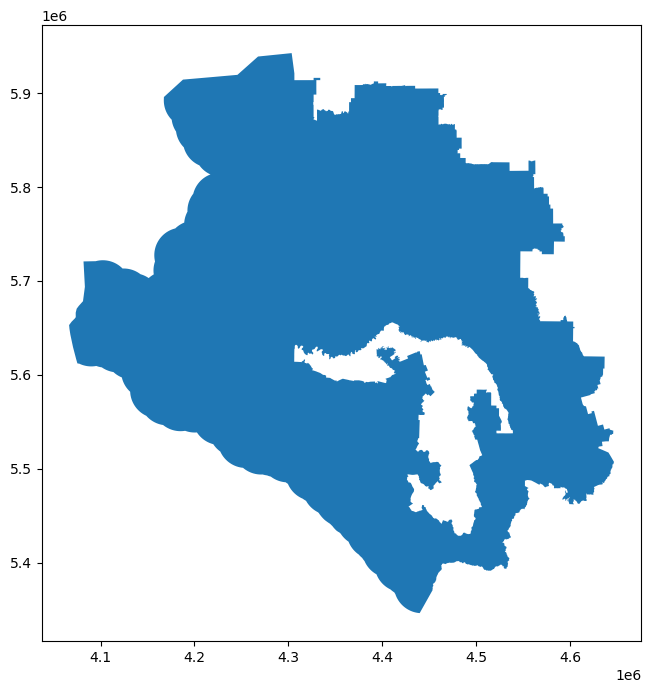

In [21]:
kk = ox.geocode_to_gdf("Krasnodar Krai, Russia")
kk = kk.to_crs(epsg=3857)
print(f"Площадь Краснодарского края: {kk.geometry.area.sum() / 1e6:,.0f} км²")
kk.plot(figsize=(10, 8))
plt.show()

In [22]:
if os.path.exists("../data/processed/grid_kk.gpkg"):
    grid_kk = gpd.read_file("../data/processed/grid_kk.gpkg")
    print(f"Сетка KK загружена с диска: {len(grid_kk):,} ячеек")
else:
    grid_kk = build_grid(kk)
    grid_kk.to_file("../data/processed/grid_kk.gpkg", driver="GPKG")
    print(f"Сетка KK построена и сохранена: {len(grid_kk):,} ячеек")

Сетка KK загружена с диска: 185,691 ячеек


In [23]:
cities_kk_wgs84 = {
    'Краснодар': (38.9753, 45.0355),
    'Сочи': (39.7233, 43.5853),
    'Новороссийск': (37.7615, 44.7239),
    'Армавир': (41.1289, 44.9892),
    'Анапа': (37.3158, 44.8946),
    'Геленджик': (38.0699, 44.5622),
    'Туапсе': (39.0779, 44.0974),
    'Ейск': (38.2766, 46.7104),
    'Тихорецк': (40.1283, 45.8536),
}

cities_kk = gpd.GeoDataFrame(
    {'city': list(cities_kk_wgs84.keys())},
    geometry=[Point(lon, lat) for lon, lat in cities_kk_wgs84.values()],
    crs='EPSG:4326'
).to_crs(epsg=3857)

grid_kk['centroid'] = grid_kk.geometry.centroid
krasnodar_point = cities_kk[cities_kk['city'] == 'Краснодар'].geometry.iloc[0]
grid_kk['dist_to_center_km'] = grid_kk['centroid'].distance(krasnodar_point) / 1000
grid_kk['dist_to_city_km'] = grid_kk['centroid'].apply(
    lambda p: min(p.distance(c) for c in cities_kk.geometry) / 1000
)

print("посчитан")

посчитан


In [24]:
X_otgr_kk = 59.7

grid_kk['baseline_otgr'] = X_otgr_kk * grid_kk['area_km2'] / grid_kk['area_km2'].sum()

grid_kk['otgr_weight'] = 0.7 / (grid_kk['dist_to_center_km'] + 1) + 0.3 / (grid_kk['dist_to_city_km'] + 1)
grid_kk['method_otgr'] = X_otgr_kk * grid_kk['otgr_weight'] / grid_kk['otgr_weight'].sum()

print(f"Отгрузка: сумма {grid_kk['method_otgr'].sum():.2f} / {X_otgr_kk}")

Отгрузка: сумма 59.70 / 59.7


In [25]:
X_shx_kk = 186744.8

grid_kk['baseline_shx'] = X_shx_kk * grid_kk['area_km2'] / grid_kk['area_km2'].sum()

grid_kk['shx_weight'] = grid_kk['dist_to_city_km'] / (grid_kk['dist_to_center_km'] + 1)
grid_kk['method_shx'] = X_shx_kk * grid_kk['shx_weight'] / grid_kk['shx_weight'].sum()

print(f"С/х: сумма {grid_kk['method_shx'].sum():.2f} / {X_shx_kk}")

С/х: сумма 186744.80 / 186744.8


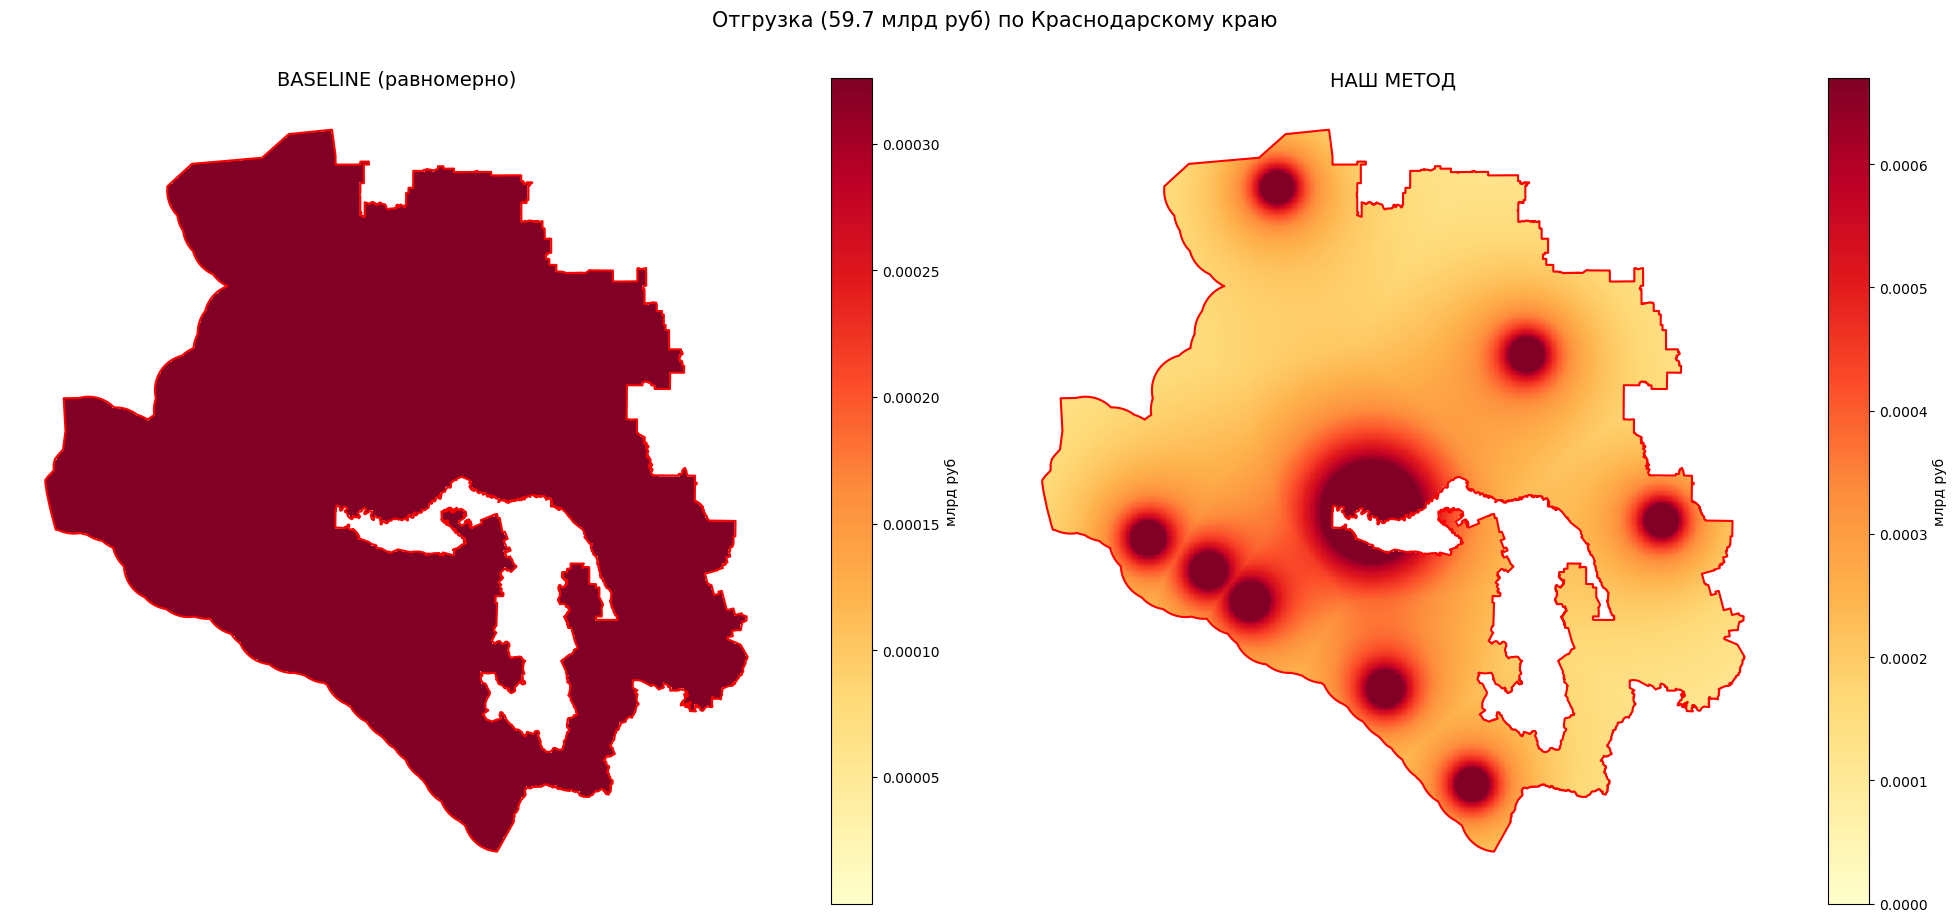

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

grid_kk.plot(column='baseline_otgr', ax=axes[0], cmap='YlOrRd', legend=True,
             legend_kwds={'label': 'млрд руб'})
kk.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE (равномерно)', fontsize=14)
axes[0].set_axis_off()

vmax = grid_kk['method_otgr'].quantile(0.95)
grid_kk.plot(column='method_otgr', ax=axes[1], cmap='YlOrRd', legend=True, vmin=0, vmax=vmax,
             legend_kwds={'label': 'млрд руб'})
kk.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД', fontsize=14)
axes[1].set_axis_off()

plt.suptitle(f'Отгрузка ({X_otgr_kk} млрд руб) по Краснодарскому краю', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_kk_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

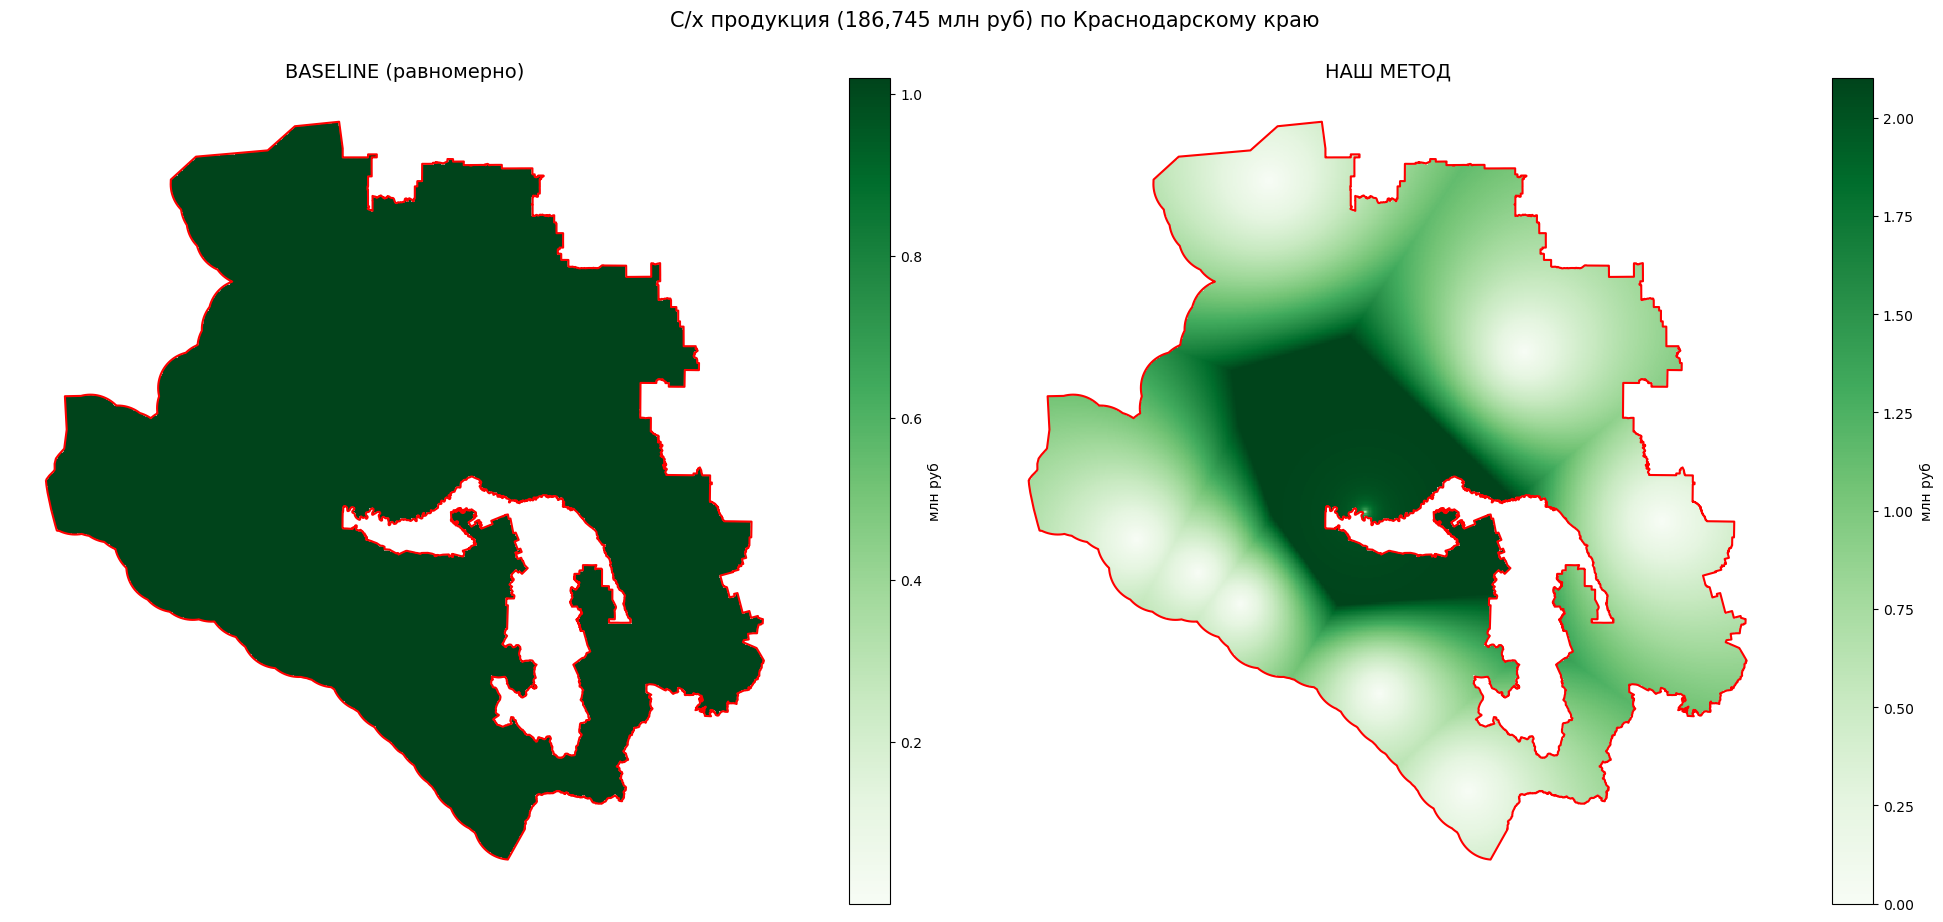

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

grid_kk.plot(column='baseline_shx', ax=axes[0], cmap='Greens', legend=True,
             legend_kwds={'label': 'млн руб'})
kk.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title('BASELINE (равномерно)', fontsize=14)
axes[0].set_axis_off()

vmax = grid_kk['method_shx'].quantile(0.95)
grid_kk.plot(column='method_shx', ax=axes[1], cmap='Greens', legend=True, vmin=0, vmax=vmax,
             legend_kwds={'label': 'млн руб'})
kk.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('НАШ МЕТОД', fontsize=14)
axes[1].set_axis_off()

plt.suptitle(f'С/х продукция ({X_shx_kk:,.0f} млн руб) по Краснодарскому краю', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_kk_agriculture.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
gini_b_otgr = gini(grid_kk['baseline_otgr'].values)
gini_m_otgr = gini(grid_kk['method_otgr'].values)
gini_b_shx = gini(grid_kk['baseline_shx'].values)
gini_m_shx = gini(grid_kk['method_shx'].values)

print(f"Краснодарский край:")
print(f"  Отгрузка — Джини: baseline {gini_b_otgr:.3f} vs method {gini_m_otgr:.3f}")
print(f"  С/х      — Джини: baseline {gini_b_shx:.3f} vs method {gini_m_shx:.3f}")

Краснодарский край:
  Отгрузка — Джини: baseline 0.014 vs method 0.303
  С/х      — Джини: baseline 0.014 vs method 0.350


Якутия (центр): 160,000 км²


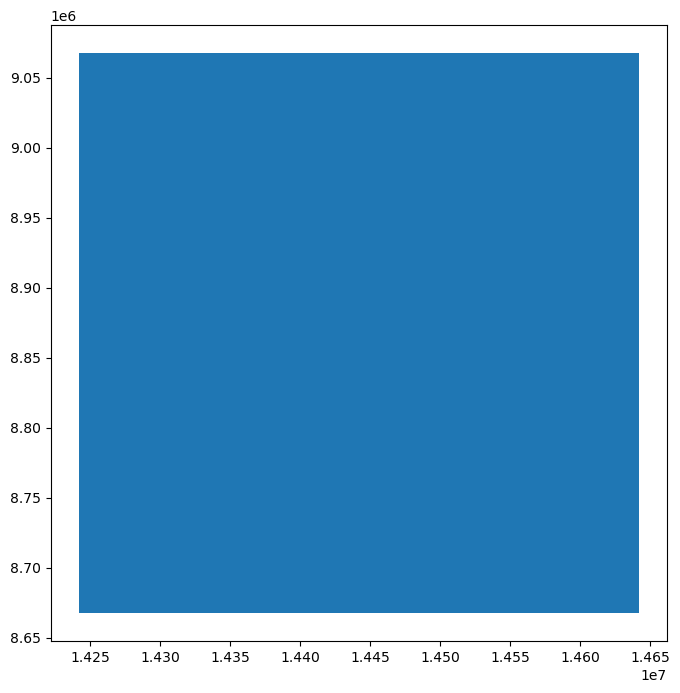

In [29]:
from shapely.geometry import box as shp_box

ya_full = ox.geocode_to_gdf("Sakha Republic, Russia")
ya_full = ya_full.to_crs(epsg=3857)

yakutsk_wgs = (129.7322, 62.0355)
yakutsk_3857 = gpd.GeoDataFrame(
    geometry=[Point(*yakutsk_wgs)], crs='EPSG:4326'
).to_crs(epsg=3857).geometry.iloc[0]

half_size = 200_000
bbox = shp_box(
    yakutsk_3857.x - half_size, yakutsk_3857.y - half_size,
    yakutsk_3857.x + half_size, yakutsk_3857.y + half_size
)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs='EPSG:3857')

ya = gpd.overlay(ya_full, bbox_gdf, how='intersection')
print(f"Якутия (центр): {ya.geometry.area.sum() / 1e6:,.0f} км²")
ya.plot(figsize=(10, 8))
plt.show()

In [30]:
if os.path.exists("../data/processed/grid_ya.gpkg"):
    grid_ya = gpd.read_file("../data/processed/grid_ya.gpkg")
    print(f"Сетка Якутии загружена с диска: {len(grid_ya):,} ячеек")
else:
    grid_ya = build_grid(ya)
    grid_ya.to_file("../data/processed/grid_ya.gpkg", driver="GPKG")
    print(f"Сетка Якутии построена и сохранена: {len(grid_ya):,} ячеек")

Сетка Якутии загружена с диска: 160,801 ячеек


In [31]:
cities_ya_wgs84 = {
    'Якутск': (129.7322, 62.0355),
    'Нерюнгри': (124.7283, 56.6589),
    'Алдан': (125.3914, 58.6017),
    'Мирный': (113.9881, 62.5350),
    'Вилюйск': (121.6450, 63.7475),
    'Покровск': (129.1486, 61.4856),
}

cities_ya = gpd.GeoDataFrame(
    {'city': list(cities_ya_wgs84.keys())},
    geometry=[Point(lon, lat) for lon, lat in cities_ya_wgs84.values()],
    crs='EPSG:4326'
).to_crs(epsg=3857)

grid_ya['centroid'] = grid_ya.geometry.centroid
yakutsk_pt = cities_ya[cities_ya['city'] == 'Якутск'].geometry.iloc[0]
grid_ya['dist_to_center_km'] = grid_ya['centroid'].distance(yakutsk_pt) / 1000
grid_ya['dist_to_city_km'] = grid_ya['centroid'].apply(
    lambda p: min(p.distance(c) for c in cities_ya.geometry) / 1000
)
print("посчитан")

посчитан


In [32]:
X_otgr_ya = 11.2

grid_ya['baseline_otgr'] = X_otgr_ya * grid_ya['area_km2'] / grid_ya['area_km2'].sum()
grid_ya['otgr_weight'] = 0.7 / (grid_ya['dist_to_center_km'] + 1) + 0.3 / (grid_ya['dist_to_city_km'] + 1)
grid_ya['method_otgr'] = X_otgr_ya * grid_ya['otgr_weight'] / grid_ya['otgr_weight'].sum()

print(f"Отгрузка: {grid_ya['method_otgr'].sum():.2f} / {X_otgr_ya}")

Отгрузка: 11.20 / 11.2


In [33]:
X_shx_ya = 25431.3

grid_ya['baseline_shx'] = X_shx_ya * grid_ya['area_km2'] / grid_ya['area_km2'].sum()
grid_ya['shx_weight'] = grid_ya['dist_to_city_km'] / (grid_ya['dist_to_center_km'] + 1)
grid_ya['method_shx'] = X_shx_ya * grid_ya['shx_weight'] / grid_ya['shx_weight'].sum()

print(f"С/х: {grid_ya['method_shx'].sum():.2f} / {X_shx_ya}")

С/х: 25431.30 / 25431.3


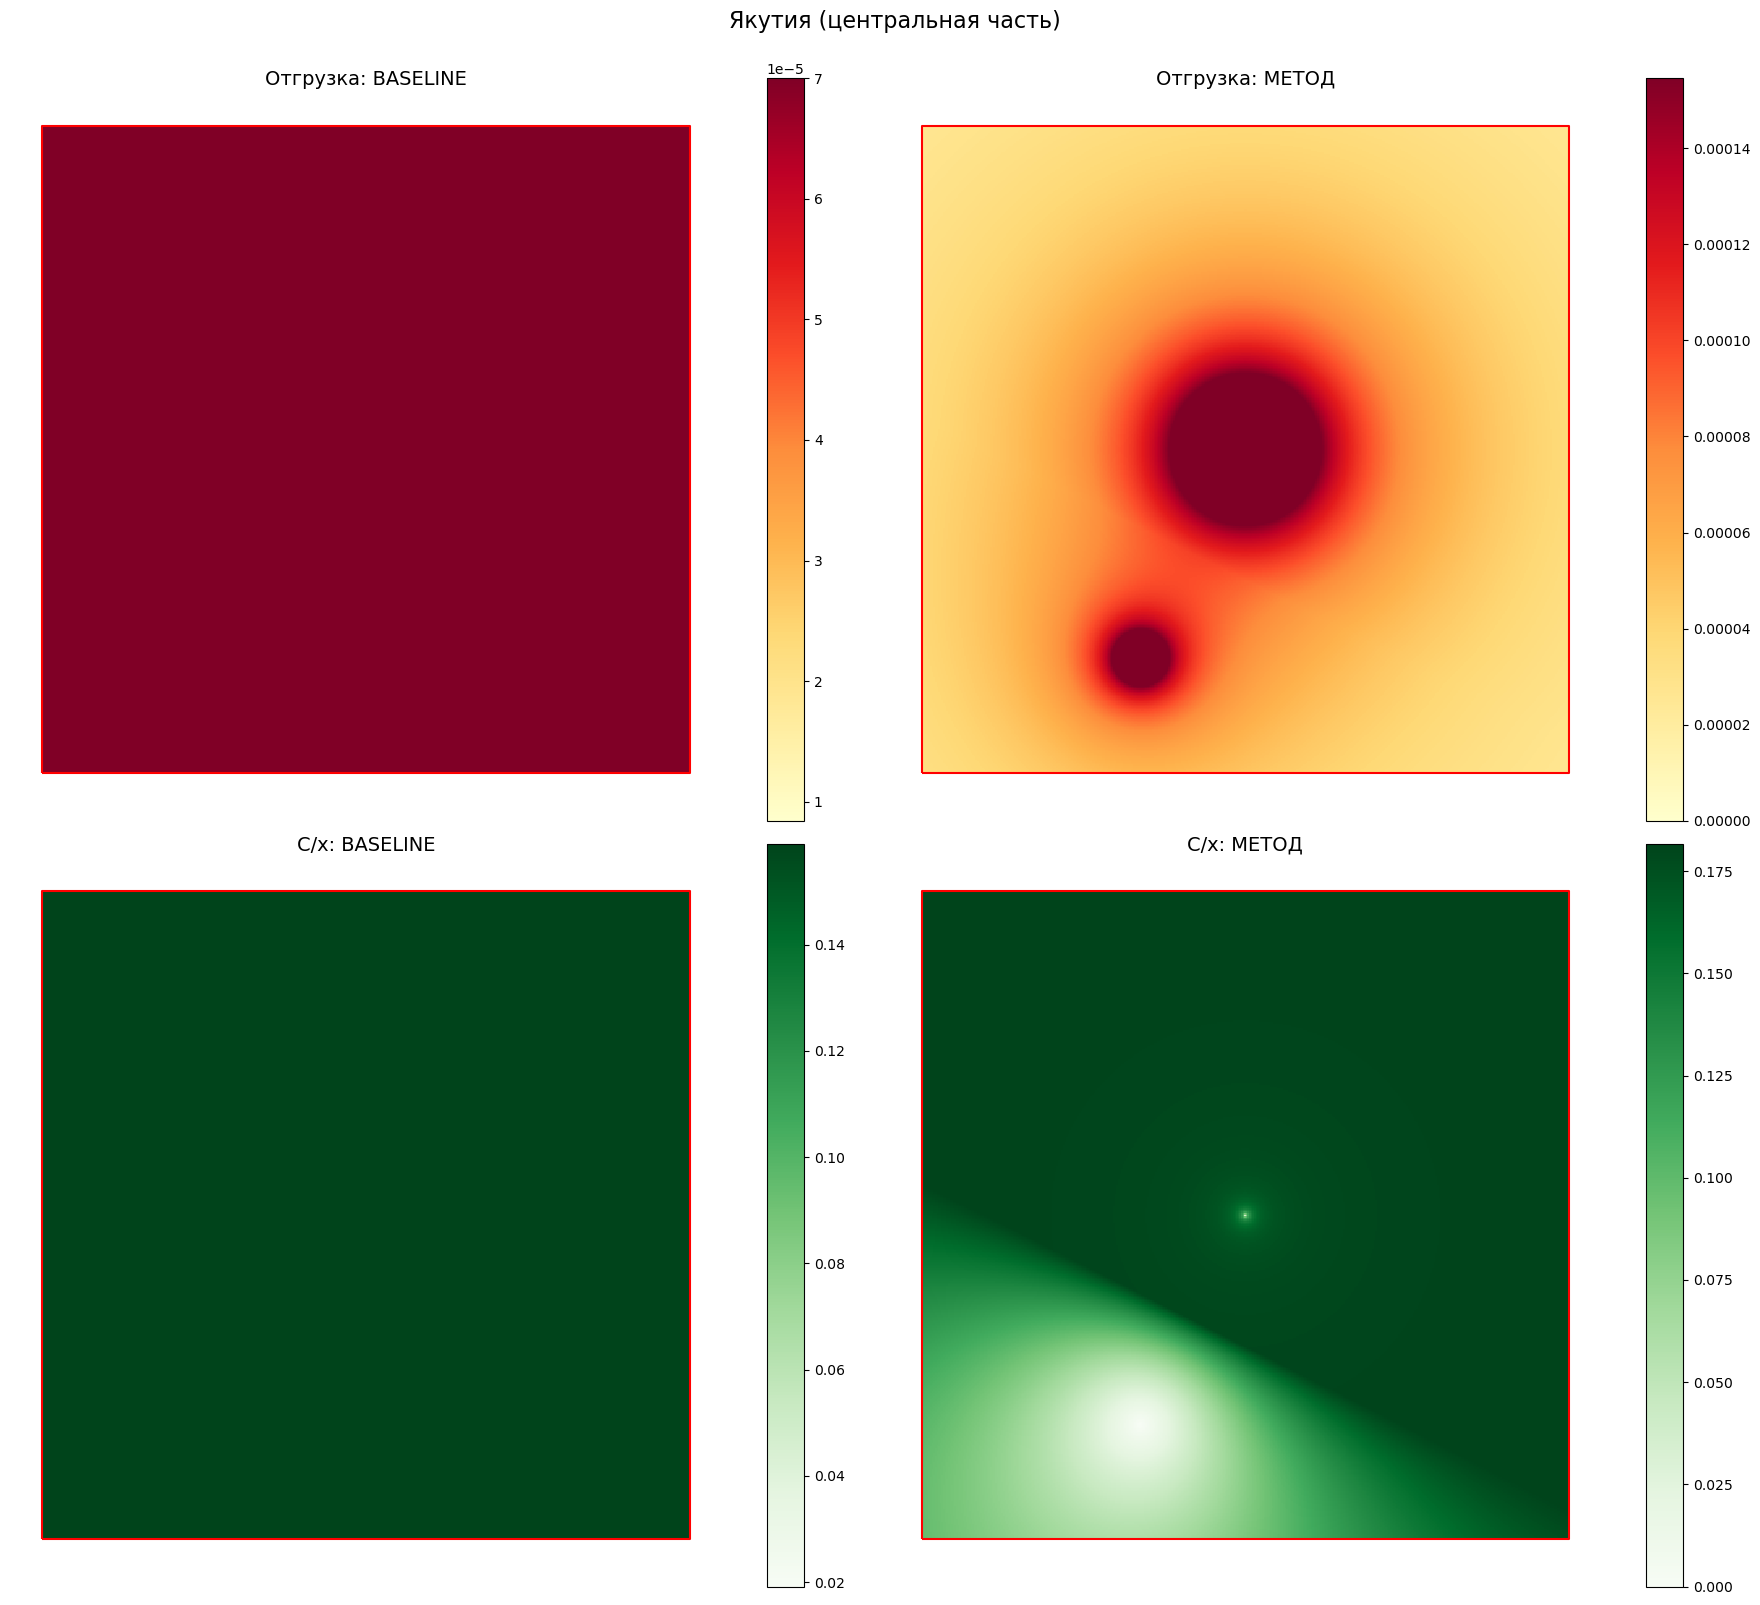

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

grid_ya.plot(column='baseline_otgr', ax=axes[0,0], cmap='YlOrRd', legend=True)
ya.boundary.plot(ax=axes[0,0], color='red', linewidth=1.5)
axes[0,0].set_title('Отгрузка: BASELINE', fontsize=14)
axes[0,0].set_axis_off()

vmax = grid_ya['method_otgr'].quantile(0.95)
grid_ya.plot(column='method_otgr', ax=axes[0,1], cmap='YlOrRd', legend=True, vmin=0, vmax=vmax)
ya.boundary.plot(ax=axes[0,1], color='red', linewidth=1.5)
axes[0,1].set_title('Отгрузка: МЕТОД', fontsize=14)
axes[0,1].set_axis_off()

grid_ya.plot(column='baseline_shx', ax=axes[1,0], cmap='Greens', legend=True)
ya.boundary.plot(ax=axes[1,0], color='red', linewidth=1.5)
axes[1,0].set_title('С/х: BASELINE', fontsize=14)
axes[1,0].set_axis_off()

vmax = grid_ya['method_shx'].quantile(0.95)
grid_ya.plot(column='method_shx', ax=axes[1,1], cmap='Greens', legend=True, vmin=0, vmax=vmax)
ya.boundary.plot(ax=axes[1,1], color='red', linewidth=1.5)
axes[1,1].set_title('С/х: МЕТОД', fontsize=14)
axes[1,1].set_axis_off()

plt.suptitle('Якутия (центральная часть)', fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig('../results/comparison_ya.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print("Якутия (центр):")
print(f"  Отгрузка — Джини: baseline {gini(grid_ya['baseline_otgr'].values):.3f} vs method {gini(grid_ya['method_otgr'].values):.3f}")
print(f"  С/х      — Джини: baseline {gini(grid_ya['baseline_shx'].values):.3f} vs method {gini(grid_ya['method_shx'].values):.3f}")

Якутия (центр):
  Отгрузка — Джини: baseline 0.005 vs method 0.331
  С/х      — Джини: baseline 0.005 vs method 0.117


In [36]:
import os
for p in ['../data/raw', '../data/raw', 'data/raw']:
    if os.path.exists(p):
        print(f"найдена: {p}")
        print(os.listdir(p))

найдена: ../data/raw
['Массив Данных в формате Parquet', 'Корпус статистических данных', '.DS_Store', 'worldpop', 'Описание возможных направлений поиска', 'Статистика Федстата и Росстата']
найдена: ../data/raw
['Массив Данных в формате Parquet', 'Корпус статистических данных', '.DS_Store', 'worldpop', 'Описание возможных направлений поиска', 'Статистика Федстата и Росстата']


In [37]:
import pandas as pd

df = pd.read_parquet("../data/raw/Массив Данных в формате Parquet/Показатели по регионам.parquet")

df_train_otgr = df[(df['indicator_code'] == 'Y477090007') & 
                    (df['object_level'] == 'Регион') & 
                    (df['year'] == 2024)].copy()
df_train_otgr = df_train_otgr[['object_name', 'indicator_value']].rename(
    columns={'indicator_value': 'otgr'}
)
df_train_otgr = df_train_otgr.dropna()
print(f"Регионов с данными: {len(df_train_otgr)}")
df_train_otgr.head()

Регионов с данными: 348


,object_name,otgr
873708,Алтайский край,17.5
873716,Амурская область,5.4
873724,Архангельская область (без автономного округа),10.1
873732,Архангельская область (с автономным округом),10.9
873740,Астраханская область,8.3


In [38]:
keywords = ['численность населения', 'городское население', 'плотность населения', 'площадь территории']
for kw in keywords:
    found = df[df['indicator_name'].str.contains(kw, case=False, na=False)]
    n = found['indicator_code'].nunique()
    print(f"=== '{kw}': {n} индикаторов ===")
    if n > 0:
        print(found[['indicator_code', 'indicator_name']].drop_duplicates().head(5).to_string())
        print()

=== 'численность населения': 11 индикаторов ===
       indicator_code                                                                                                           indicator_name
107090     Y477130058                                                                                                    Численность населения
155386     Y477130059                                                         Численность населения с денежными доходами ниже границы бедности
155578     Y477130060                        Численность населения с денежными доходами ниже границы бедности / величины прожиточного минимума
298849     Y477110213                                      Нагрузка на работников сферы здравоохранения: Численность населения на одного врача
301153     Y477110214  Нагрузка на работников сферы здравоохранения: Численность населения на одного работника среднего медицинского персонала

=== 'городское население': 1 индикаторов ===
        indicator_code                          

In [39]:
keywords = ['инвестиции в основной', 'среднесписочная численность', 'число предприятий', 'оборот рознич']
for kw in keywords:
    found = df[df['indicator_name'].str.contains(kw, case=False, na=False)]
    n = found['indicator_code'].nunique()
    print(f"=== '{kw}': {n} ===")
    if n > 0:
        print(found[['indicator_code', 'indicator_name']].drop_duplicates().head(3).to_string())
        print()

=== 'инвестиции в основной': 11 ===
       indicator_code                                   indicator_name
346657     Y477110107                    Инвестиции в основной капитал
348961     Y477110108  Инвестиции в основной капитал на душу населения
365185     Y477050015                    Инвестиции в основной капитал

=== 'среднесписочная численность': 5 ===
        indicator_code                                                                                              indicator_name
228481      Y477040035                                       Среднесписочная численность работников в организациях здравоохранения
749238      Y477110184               Итоги сплошных наблюдений: Среднесписочная численность работников (без внешних совместителей)
1102483     Y477110264  Основные показатели по виду деятельности лесозаготовки: Среднесписочная численность работников организаций

=== 'число предприятий': 0 ===
=== 'оборот рознич': 9 ===
       indicator_code                                  

In [40]:
def get_region_values(indicator_code, year=2024):
    rows = df[(df['indicator_code'] == indicator_code) & 
              (df['object_level'] == 'Регион') & 
              (df['year'] == year)].copy()
    return rows[['object_name', 'indicator_value']].dropna()

pop = get_region_values('Y477130058').rename(columns={'indicator_value': 'population'})
urban = get_region_values('Y477010002').rename(columns={'indicator_value': 'urban_pop'})
invest = get_region_values('Y477110107').rename(columns={'indicator_value': 'investments'})

train = df_train_otgr.merge(pop, on='object_name', how='inner') \
                     .merge(urban, on='object_name', how='inner') \
                     .merge(invest, on='object_name', how='inner')

print(f"Регионов в выборке: {len(train)}")
train.head()

Регионов в выборке: 0


,object_name,otgr,population,urban_pop,investments


In [41]:
print(f"Отгрузка 2024: {len(df_train_otgr)} регионов")
print(f"Население 2024: {len(pop)} регионов")
print(f"Городское нас. 2024: {len(urban)} регионов")
print(f"Инвестиции 2024: {len(invest)} регионов")

Отгрузка 2024: 348 регионов
Население 2024: 0 регионов
Городское нас. 2024: 0 регионов
Инвестиции 2024: 87 регионов


In [42]:
pop = get_region_values('Y477130058', year=2023).rename(columns={'indicator_value': 'population'})
urban = get_region_values('Y477010002', year=2023).rename(columns={'indicator_value': 'urban_pop'})
invest = get_region_values('Y477110107', year=2023).rename(columns={'indicator_value': 'investments'})
otgr_2023 = get_region_values('Y477090007', year=2023).rename(columns={'indicator_value': 'otgr'})

otgr_2023 = otgr_2023.groupby('object_name', as_index=False)['otgr'].sum()

print(f"Отгрузка 2023: {len(otgr_2023)} регионов")
print(f"Население 2023: {len(pop)} регионов")
print(f"Городское нас. 2023: {len(urban)} регионов")
print(f"Инвестиции 2023: {len(invest)} регионов")

Отгрузка 2023: 87 регионов
Население 2023: 783 регионов
Городское нас. 2023: 87 регионов
Инвестиции 2023: 87 регионов


In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression

pop_agg = pop.groupby('object_name', as_index=False)['population'].sum()

train = otgr_2023.merge(pop_agg, on='object_name', how='inner') \
                 .merge(urban, on='object_name', how='inner') \
                 .merge(invest, on='object_name', how='inner')

train_clean = train.dropna()
train_clean = train_clean[(train_clean['otgr'] > 0) & 
                            (train_clean['population'] > 0) & 
                            (train_clean['urban_pop'] > 0) & 
                            (train_clean['investments'] > 0)].copy()

print(f"После очистки: {len(train_clean)} регионов")

X = np.log1p(train_clean[['population', 'urban_pop', 'investments']].values)
y = np.log1p(train_clean['otgr'].values)

model = LinearRegression()
model.fit(X, y)

print(f"R²: {model.score(X, y):.3f}")
print(f"Коэффициенты: население {model.coef_[0]:.3f}, городское {model.coef_[1]:.3f}, инвестиции {model.coef_[2]:.3f}")

После очистки: 85 регионов
R²: 0.837
Коэффициенты: население -2.556, городское 2.771, инвестиции 0.701


In [44]:
pop = pop.groupby('object_name', as_index=False)['population'].sum()

train = otgr_2023.merge(pop, on='object_name', how='inner') \
                 .merge(urban, on='object_name', how='inner') \
                 .merge(invest, on='object_name', how='inner')

print(f"Регионов в выборке: {len(train)}")
train.head()

Регионов в выборке: 87


,object_name,otgr,population,urban_pop,investments
0,Алтайский край,676.5,8523.6,1242.7,185655.0
1,Амурская область,359.1,3024.8,517.0,745544.0
2,Архангельская область (без автономного округа),505.2,3857.2,750.6,119660.0
3,Архангельская область (с автономным округом),1071.0,4022.8,781.4,206088.0
4,Астраханская область,596.3,3802.4,609.0,89373.0


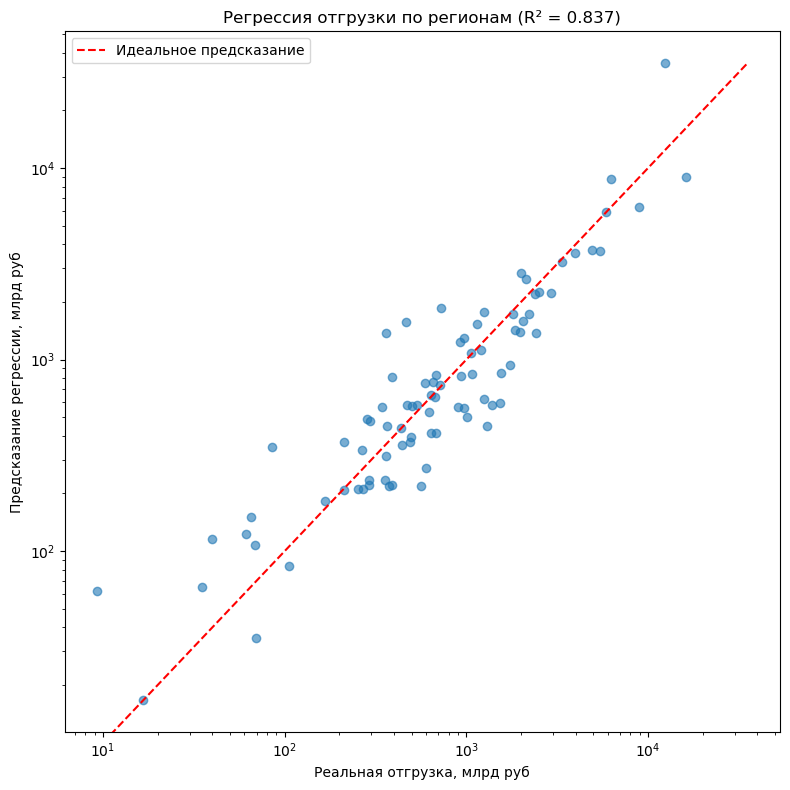

In [45]:
train_clean['otgr_pred'] = np.expm1(model.predict(X))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(train_clean['otgr'], train_clean['otgr_pred'], alpha=0.6)
max_v = max(train_clean['otgr'].max(), train_clean['otgr_pred'].max())
ax.plot([0, max_v], [0, max_v], 'r--', label='Идеальное предсказание')
ax.set_xlabel('Реальная отгрузка, млрд руб')
ax.set_ylabel('Предсказание регрессии, млрд руб')
ax.set_title(f'Регрессия отгрузки по регионам (R² = {model.score(X, y):.3f})')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../results/regression_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
print("pop:", len(pop), pop.columns.tolist() if hasattr(pop, 'columns') else 'нет колонок')
print("urban:", len(urban), urban.columns.tolist())
print("invest:", len(invest), invest.columns.tolist())
print("otgr_2023:", len(otgr_2023), otgr_2023.columns.tolist())
print()
print("Образец из otgr_2023:")
print(otgr_2023.head(3))
print()
print("Образец из urban:")
print(urban.head(3))

pop: 87 ['object_name', 'population']
urban: 87 ['object_name', 'urban_pop']
invest: 87 ['object_name', 'investments']
otgr_2023: 87 ['object_name', 'otgr']

Образец из otgr_2023:
                                      object_name   otgr
0                                  Алтайский край  676.5
1                                Амурская область  359.1
2  Архангельская область (без автономного округа)  505.2

Образец из urban:
                                            object_name  urban_pop
1960960                                  Алтайский край     1242.7
1960975                                Амурская область      517.0
1960990  Архангельская область (без автономного округа)      750.6


In [47]:
import numpy as np
from sklearn.linear_model import LinearRegression

pop_agg = pop.groupby('object_name', as_index=False)['population'].sum()

train = otgr_2023.merge(pop_agg, on='object_name', how='inner') \
                 .merge(urban, on='object_name', how='inner') \
                 .merge(invest, on='object_name', how='inner')

print(f"Регионов в выборке: {len(train)}")

train_clean = train.dropna()
train_clean = train_clean[(train_clean['otgr'] > 0) & 
                            (train_clean['population'] > 0) & 
                            (train_clean['urban_pop'] > 0) & 
                            (train_clean['investments'] > 0)].copy()

print(f"После очистки: {len(train_clean)} регионов")

X = np.log1p(train_clean[['population', 'urban_pop', 'investments']].values)
y = np.log1p(train_clean['otgr'].values)

model = LinearRegression()
model.fit(X, y)

print(f"R²: {model.score(X, y):.3f}")
print(f"Коэффициенты: население {model.coef_[0]:.3f}, городское {model.coef_[1]:.3f}, инвестиции {model.coef_[2]:.3f}")

Регионов в выборке: 87
После очистки: 85 регионов
R²: 0.837
Коэффициенты: население -2.556, городское 2.771, инвестиции 0.701


In [48]:
import rioxarray as rxr

pop_raster = rxr.open_rasterio("../data/raw/worldpop/russia_pop_2020.tif")
print(f"CRS: {pop_raster.rio.crs}")
print(f"Размер: {pop_raster.shape}")

CRS: EPSG:4326
Размер: (1, 48803, 432000)


In [49]:
from rasterstats import zonal_stats

grid_mo_4326 = grid_mo.to_crs(epsg=4326)

stats = zonal_stats(
    grid_mo_4326.geometry,
    "../data/processed/pop_mo_z.tif",
    stats=['sum'],
    nodata=-99999
)

grid_mo['population'] = [s['sum'] if s['sum'] is not None else 0 for s in stats]

print(f"Сумма населения в ячейках: {grid_mo['population'].sum():,.0f}")
print(f"Ячеек с населением > 0: {(grid_mo['population'] > 0).sum():,}")
print(f"Максимум в ячейке: {grid_mo['population'].max():,.0f}")

Сумма населения в ячейках: 7,432,576
Ячеек с населением > 0: 48,815
Максимум в ячейке: 5,536


In [50]:
grid_mo['method_otgr_v2'] = X_region_otgr * grid_mo['population'] / grid_mo['population'].sum()

print(f"Метод v2 (по населению):")
print(f"  Сумма: {grid_mo['method_otgr_v2'].sum():.2f} / {X_region_otgr}")
print(f"  Джини: {gini(grid_mo['method_otgr_v2'].values):.3f}")
print(f"  Сравнение:")
print(f"    Метод v1 (расстояния): Джини {gini(grid_mo['method_otgr'].values):.3f}")
print(f"    Метод v2 (население):  Джини {gini(grid_mo['method_otgr_v2'].values):.3f}")
print(f"    Baseline:              Джини {gini(grid_mo['baseline_otgr'].values):.3f}")

Метод v2 (по населению):
  Сумма: 209.00 / 209.0
  Джини: 0.910
  Сравнение:
    Метод v1 (расстояния): Джини 0.349
    Метод v2 (население):  Джини 0.910
    Baseline:              Джини 0.018


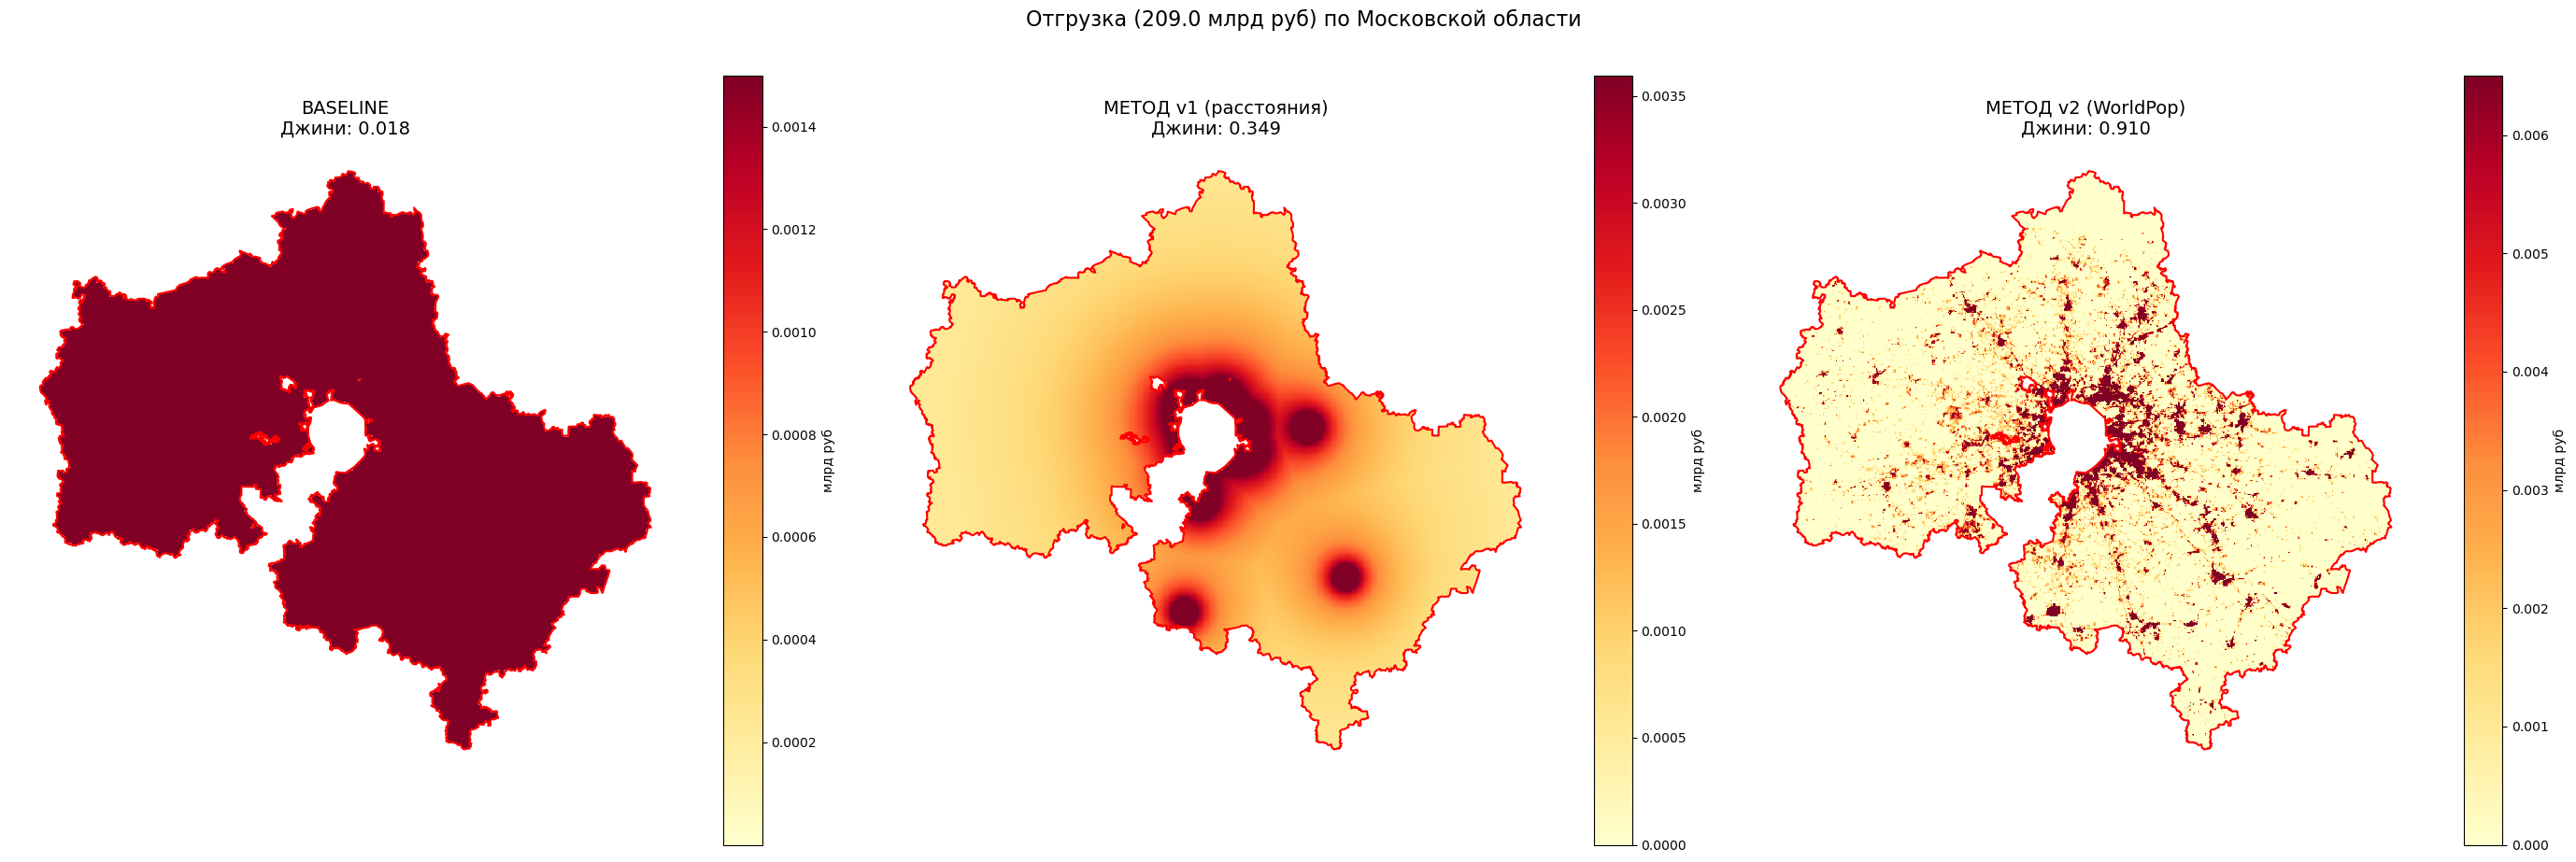

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(28, 9))

grid_mo.plot(column='baseline_otgr', ax=axes[0], cmap='YlOrRd', legend=True,
             legend_kwds={'label': 'млрд руб'})
mo.boundary.plot(ax=axes[0], color='red', linewidth=1.5)
axes[0].set_title(f'BASELINE\nДжини: {gini(grid_mo["baseline_otgr"].values):.3f}', fontsize=14)
axes[0].set_axis_off()

vmax1 = grid_mo['method_otgr'].quantile(0.95)
grid_mo.plot(column='method_otgr', ax=axes[1], cmap='YlOrRd', legend=True, vmin=0, vmax=vmax1,
             legend_kwds={'label': 'млрд руб'})
mo.boundary.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title(f'МЕТОД v1 (расстояния)\nДжини: {gini(grid_mo["method_otgr"].values):.3f}', fontsize=14)
axes[1].set_axis_off()

vmax2 = grid_mo['method_otgr_v2'].quantile(0.95)
grid_mo.plot(column='method_otgr_v2', ax=axes[2], cmap='YlOrRd', legend=True, vmin=0, vmax=vmax2,
             legend_kwds={'label': 'млрд руб'})
mo.boundary.plot(ax=axes[2], color='red', linewidth=1.5)
axes[2].set_title(f'МЕТОД v2 (WorldPop)\nДжини: {gini(grid_mo["method_otgr_v2"].values):.3f}', fontsize=14)
axes[2].set_axis_off()

plt.suptitle(f'Отгрузка ({X_region_otgr} млрд руб) по Московской области', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_shipping_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
from rasterstats import zonal_stats

grid_kk_4326 = grid_kk.to_crs(epsg=4326)

stats_kk = zonal_stats(
    grid_kk_4326.geometry,
    "../data/processed/pop_kk_z.tif",
    stats=['sum'],
    nodata=-99999
)

grid_kk['population'] = [s['sum'] if s['sum'] is not None else 0 for s in stats_kk]
grid_kk['method_otgr_v2'] = X_otgr_kk * grid_kk['population'] / grid_kk['population'].sum()

print(f"Население Краснодара в сетке: {grid_kk['population'].sum():,.0f}")
print(f"Метод v2: сумма {grid_kk['method_otgr_v2'].sum():.2f} / {X_otgr_kk}")
print(f"Джини v1={gini(grid_kk['method_otgr'].values):.3f}, v2={gini(grid_kk['method_otgr_v2'].values):.3f}")

Население Краснодара в сетке: 5,171,503
Метод v2: сумма 59.70 / 59.7
Джини v1=0.303, v2=0.969


In [53]:
grid_ya_4326 = grid_ya.to_crs(epsg=4326)

stats_ya = zonal_stats(
    grid_ya_4326.geometry,
    "../data/processed/pop_ya_z.tif",
    stats=['sum'],
    nodata=-99999
)

grid_ya['population'] = [s['sum'] if s['sum'] is not None else 0 for s in stats_ya]
grid_ya['method_otgr_v2'] = X_otgr_ya * grid_ya['population'] / grid_ya['population'].sum()

print(f"Население центральной Якутии: {grid_ya['population'].sum():,.0f}")
print(f"Метод v2: сумма {grid_ya['method_otgr_v2'].sum():.2f} / {X_otgr_ya}")
print(f"Джини v1={gini(grid_ya['method_otgr'].values):.3f}, v2={gini(grid_ya['method_otgr_v2'].values):.3f}")

Население центральной Якутии: 395,989
Метод v2: сумма 11.20 / 11.2
Джини v1=0.331, v2=0.995


In [54]:
ya_full = ox.geocode_to_gdf("Sakha Republic, Russia")
ya_full = ya_full.to_crs(epsg=3857)
print(f"Полная Якутия: {ya_full.geometry.area.sum() / 1e6:,.0f} км²")

Полная Якутия: 21,458,612 км²


In [55]:
def build_grid(border, cell_size=1000):
    minx, miny, maxx, maxy = border.total_bounds
    minx = np.floor(minx / cell_size) * cell_size
    miny = np.floor(miny / cell_size) * cell_size
    maxx = np.ceil(maxx / cell_size) * cell_size
    maxy = np.ceil(maxy / cell_size) * cell_size
    
    cells = []
    for x in np.arange(minx, maxx, cell_size):
        for y in np.arange(miny, maxy, cell_size):
            cells.append(box(x, y, x + cell_size, y + cell_size))
    
    grid = gpd.GeoDataFrame({'geometry': cells}, crs=border.crs)
    grid = gpd.overlay(grid, border[['geometry']], how='intersection')
    grid['cell_id'] = range(len(grid))
    grid['area_km2'] = grid.geometry.area / 1e6
    return grid

ya_bbox = ya_full.copy()
ya_bbox['geometry'] = ya_full.geometry.envelope

grid_ya_full = build_grid(ya_bbox, cell_size=10000)
print(f"Полная Якутия 10×10: {len(grid_ya_full):,} ячеек")

/opt/homebrew/Caskroom/miniconda/base/envs/spatial/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


Полная Якутия 10×10: 421,152 ячеек


In [56]:
grid_ya_full_4326 = grid_ya_full.to_crs(epsg=4326)

stats_ya_full = zonal_stats(
    grid_ya_full_4326.geometry,
    "../data/processed/pop_ya_full_z.tif",
    stats=['sum'],
    nodata=-99999
)

grid_ya_full['population'] = [s['sum'] if s['sum'] is not None else 0 for s in stats_ya_full]
grid_ya_full['method_otgr_v2'] = X_otgr_ya * grid_ya_full['population'] / grid_ya_full['population'].sum()

print(f"Население всей Якутии: {grid_ya_full['population'].sum():,.0f}")
print(f"Ячеек с населением > 0: {(grid_ya_full['population'] > 0).sum():,}")
print(f"Метод v2: сумма {grid_ya_full['method_otgr_v2'].sum():.2f} / {X_otgr_ya}")
print(f"Джини: {gini(grid_ya_full['method_otgr_v2'].values):.3f}")

KeyboardInterrupt: 

In [ ]:
print(f"Якутия полная (10×10 км):")
print(f"  ячеек всего: {len(grid_ya_full)}")
print(f"  ячеек с населением > 0: {(grid_ya_full['population']>0).sum()}")
print(f"  население: {grid_ya_full['population'].sum():,.0f}")
print(f"  Джини метода v2: {gini(grid_ya_full['method_otgr_v2']):.3f}")

In [ ]:
grid_ya_full[['cell_id','geometry','population','method_otgr_v2']].to_file(
    '../data/processed/grid_ya_full_v2.gpkg', driver='GPKG'
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

g = grid_ya_full.copy()
g['method_otgr_mln'] = g['method_otgr_v2'] * 1000

g_pop = g[g['population'] > 0]
g_method = g[g['method_otgr_mln'] > 0]

g_pop.plot(
    ax=axes[0], column='population', cmap='YlOrRd',
    linewidth=0, legend=True,
    legend_kwds={'label': 'Население, чел/ячейка', 'shrink': 0.6},
    norm=mcolors.LogNorm(vmin=1, vmax=g_pop['population'].max())
)
axes[0].set_title('Население WorldPop 2020\n(сетка 10×10 км)', fontsize=13, pad=15)
axes[0].set_axis_off()
axes[0].set_facecolor('white')

g_method.plot(
    ax=axes[1], column='method_otgr_mln', cmap='viridis',
    linewidth=0, legend=True,
    legend_kwds={'label': 'Отгрузка, млн ₽/ячейка', 'shrink': 0.6},
    norm=mcolors.LogNorm(vmin=g_method['method_otgr_mln'].min(),
                          vmax=g_method['method_otgr_mln'].max())
)
axes[1].set_title('Метод v2: разнесённая отгрузка\n(сетка 10×10 км)', fontsize=13, pad=15)
axes[1].set_axis_off()
axes[1].set_facecolor('white')

fig.suptitle(
    f'Республика Саха (Якутия) — {len(g):,} ячеек, население {g["population"].sum():,.0f} чел',
    fontsize=15, y=1.02
)
plt.tight_layout()
plt.savefig('../results/comparison_ya_full_v2.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print("сохранено: ../results/comparison_ya_full_v2.png")

In [57]:
def gini(x):
    x = np.array(x, dtype=float)
    x = x[x >= 0]
    if len(x) == 0 or x.sum() == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1)) * x) - (n+1) * x.sum()) / (n * x.sum())

def top_share(x, frac=0.1):
    x = np.array(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    x_sorted = np.sort(x)[::-1]
    k = max(1, int(len(x_sorted) * frac))
    return x_sorted[:k].sum() / x_sorted.sum()

In [58]:
ELASTICITY = 2.77

def method_v3(grid, X_region, elasticity=ELASTICITY):
    pop = grid['population'].values
    weights = np.power(pop, elasticity, where=(pop > 0), out=np.zeros_like(pop, dtype=float))
    total = weights.sum()
    if total == 0:
        return np.zeros_like(weights)
    return X_region * weights / total

X_otgr_mo = 209.0
X_otgr_kk = 59.7
X_otgr_ya = 11.2

grid_mo['method_otgr_v3'] = method_v3(grid_mo, X_otgr_mo)
grid_kk['method_otgr_v3'] = method_v3(grid_kk, X_otgr_kk)
grid_ya['method_otgr_v3'] = method_v3(grid_ya, X_otgr_ya)

for name, g in [('МО', grid_mo), ('Краснодар', grid_kk), ('Якутия центр', grid_ya)]:
    g2 = g['method_otgr_v2'].values
    g3 = g['method_otgr_v3'].values
    print(f"{name}:")
    print(f"  v2 Джини: {gini(g2):.4f}, топ-10% содержит: {top_share(g2, 0.1)*100:.1f}%")
    print(f"  v3 Джини: {gini(g3):.4f}, топ-10% содержит: {top_share(g3, 0.1)*100:.1f}%")

МО:
  v2 Джини: 0.9103, топ-10% содержит: 62.1%
  v3 Джини: 0.9928, топ-10% содержит: 99.1%
Краснодар:
  v2 Джини: 0.9689, топ-10% содержит: 56.1%
  v3 Джини: 0.9955, топ-10% содержит: 96.4%
Якутия центр:
  v2 Джини: 0.9953, топ-10% содержит: 61.2%
  v3 Джини: 0.9990, топ-10% содержит: 96.6%


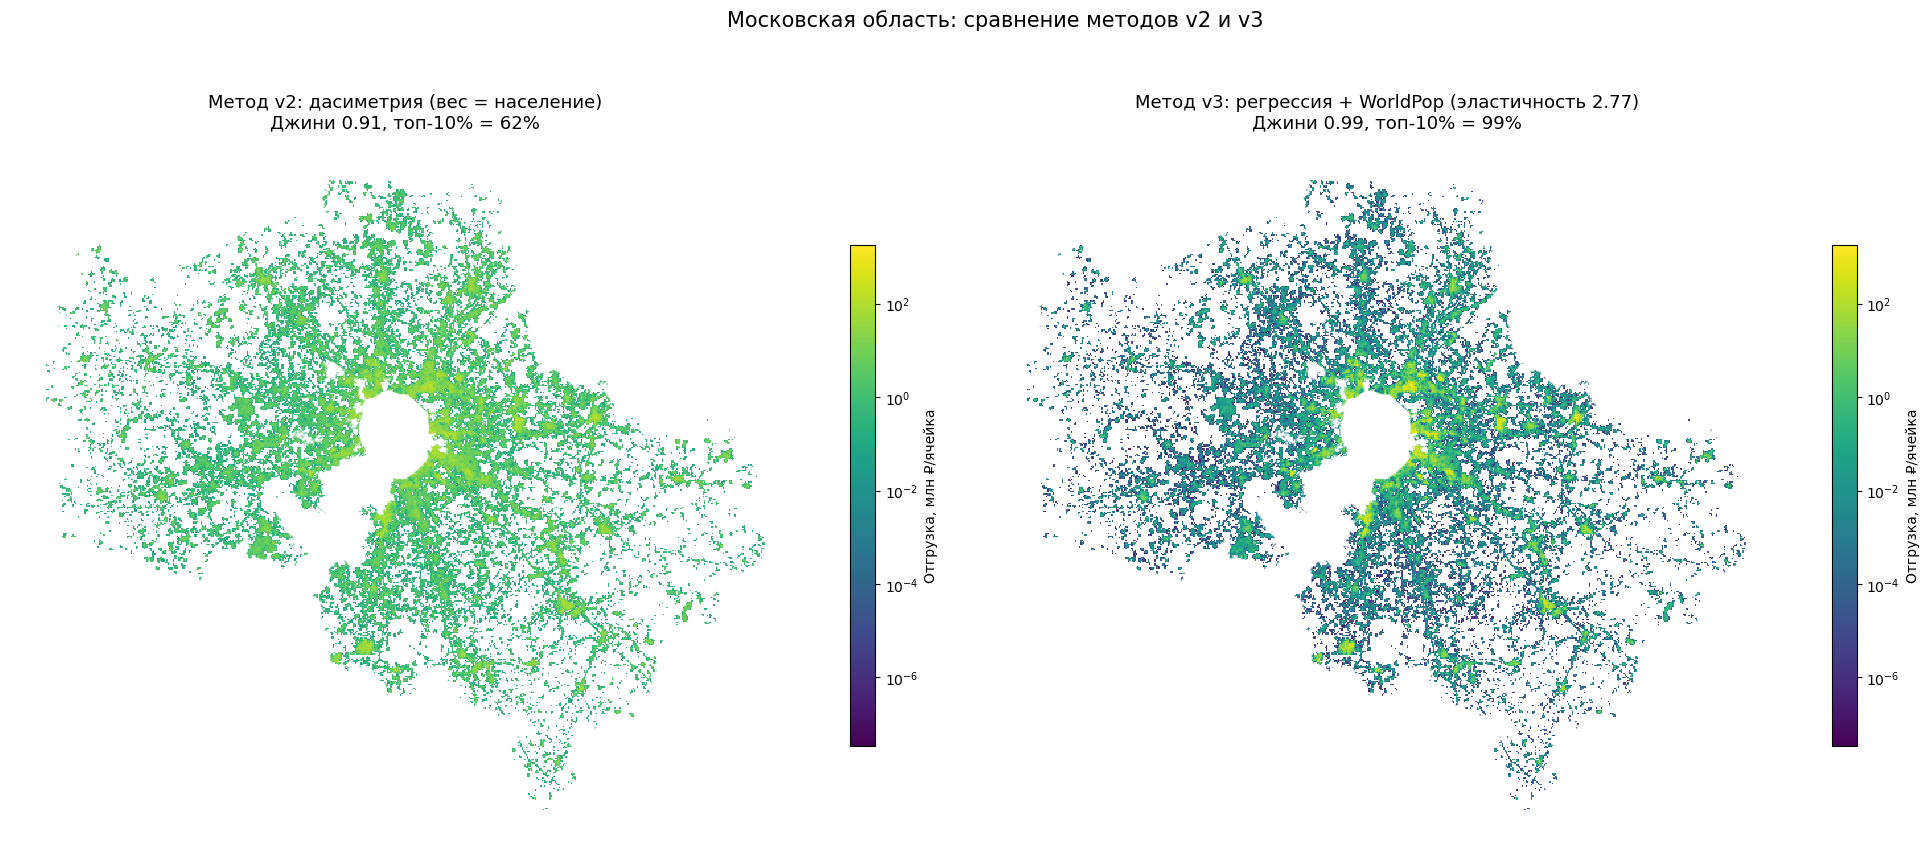

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

g_v2 = grid_mo[grid_mo['method_otgr_v2'] > 0].copy()
g_v3 = grid_mo[grid_mo['method_otgr_v3'] > 0].copy()
g_v2['mln'] = g_v2['method_otgr_v2'] * 1000
g_v3['mln'] = g_v3['method_otgr_v3'] * 1000

vmin = min(g_v2['mln'].min(), g_v3['mln'].min())
vmax = max(g_v2['mln'].max(), g_v3['mln'].max())

g_v2.plot(
    ax=axes[0], column='mln', cmap='viridis',
    linewidth=0, legend=True,
    legend_kwds={'label': 'Отгрузка, млн ₽/ячейка', 'shrink': 0.6},
    norm=mcolors.LogNorm(vmin=vmin, vmax=vmax)
)
axes[0].set_title('Метод v2: дасиметрия (вес = население)\nДжини 0.91, топ-10% = 62%', fontsize=13, pad=15)
axes[0].set_axis_off()

g_v3.plot(
    ax=axes[1], column='mln', cmap='viridis',
    linewidth=0, legend=True,
    legend_kwds={'label': 'Отгрузка, млн ₽/ячейка', 'shrink': 0.6},
    norm=mcolors.LogNorm(vmin=vmin, vmax=vmax)
)
axes[1].set_title('Метод v3: регрессия + WorldPop (эластичность 2.77)\nДжини 0.99, топ-10% = 99%', fontsize=13, pad=15)
axes[1].set_axis_off()

fig.suptitle('Московская область: сравнение методов v2 и v3', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/comparison_mo_v2_v3.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

In [60]:
print(train.columns.tolist())
print(train.head(2))

['object_name', 'otgr', 'population', 'urban_pop', 'investments']
        object_name   otgr  population  urban_pop  investments
0    Алтайский край  676.5      8523.6     1242.7     185655.0
1  Амурская область  359.1      3024.8      517.0     745544.0


In [61]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

t = train[(train['population'] > 0) & (train['urban_pop'] > 0) & 
          (train['investments'] > 0) & (train['otgr'] > 0)].copy()

X = np.column_stack([
    np.log1p(t['population']),
    np.log1p(t['urban_pop']),
    np.log1p(t['investments'])
])
y = np.log1p(t['otgr'].values)

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print(f"In-sample R²: 0.84 (на тех же данных, на которых обучали)")
print(f"\n5-fold кросс-валидация:")
for i, score in enumerate(r2_scores, 1):
    print(f"  fold {i}: {score:.3f}")
print(f"\nСреднее R² на отложенных регионах: {r2_scores.mean():.3f}")
print(f"Стандартное отклонение: {r2_scores.std():.3f}")

In-sample R²: 0.84 (на тех же данных, на которых обучали)

5-fold кросс-валидация:
  fold 1: 0.744
  fold 2: 0.806
  fold 3: 0.706
  fold 4: 0.861
  fold 5: 0.792

Среднее R² на отложенных регионах: 0.782
Стандартное отклонение: 0.053


Топ-5 регионов, где модель сильно ошиблась (по модулю остатка):
                 object_name  otgr   predicted  residual
        Республика Ингушетия   9.3   61.623056 -1.804990
         Республика Дагестан  84.9  348.393778 -1.403016
            Амурская область 359.1 1371.720382 -1.338168
             Приморский край 467.5 1572.343498 -1.211422
Еврейская автономная область  39.7  116.075800 -1.056593


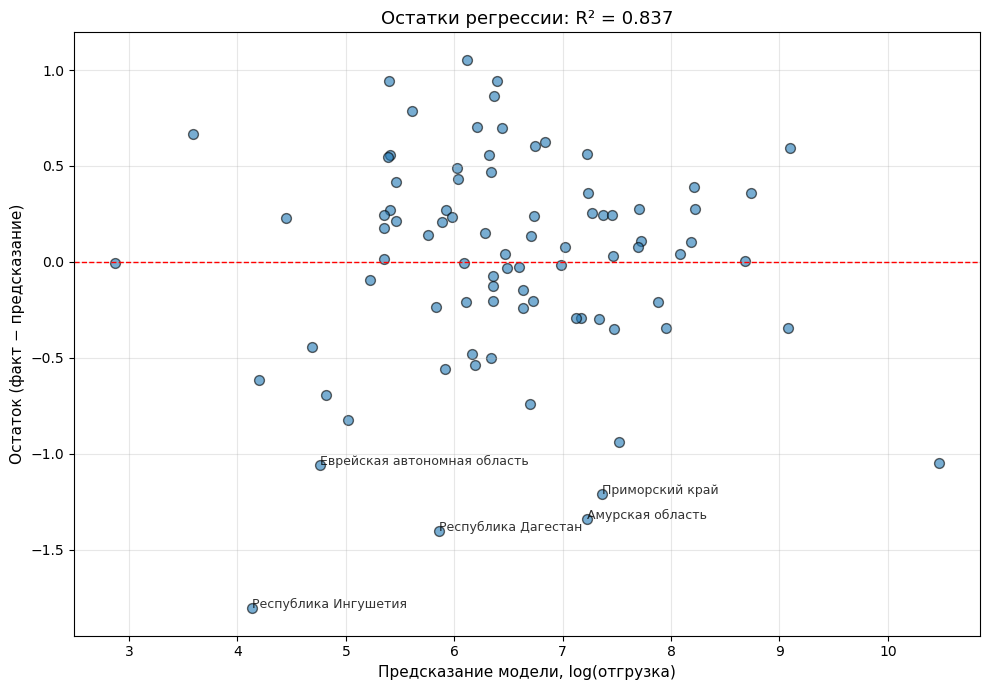

In [62]:
import matplotlib.pyplot as plt

t = train[(train['population'] > 0) & (train['urban_pop'] > 0) & 
          (train['investments'] > 0) & (train['otgr'] > 0)].copy()

X_full = np.column_stack([
    np.log1p(t['population']),
    np.log1p(t['urban_pop']),
    np.log1p(t['investments'])
])
y_full = np.log1p(t['otgr'].values)

model = LinearRegression()
model.fit(X_full, y_full)
y_pred = model.predict(X_full)
residuals = y_full - y_pred

t['predicted'] = np.expm1(y_pred)
t['residual'] = residuals
t['abs_residual'] = np.abs(residuals)

print("Топ-5 регионов, где модель сильно ошиблась (по модулю остатка):")
top_outliers = t.nlargest(5, 'abs_residual')[['object_name', 'otgr', 'predicted', 'residual']]
print(top_outliers.to_string(index=False))

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.scatter(y_pred, residuals, alpha=0.6, s=50, edgecolor='k')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)

for _, row in top_outliers.iterrows():
    idx = t.index[t['object_name'] == row['object_name']][0]
    ax.annotate(row['object_name'], 
                xy=(y_pred[t.index.get_loc(idx)], residuals[t.index.get_loc(idx)]),
                fontsize=9, alpha=0.8)

ax.set_xlabel('Предсказание модели, log(отгрузка)', fontsize=11)
ax.set_ylabel('Остаток (факт − предсказание)', fontsize=11)
ax.set_title(f'Остатки регрессии: R² = {model.score(X_full, y_full):.3f}', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/regression_residuals.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## Карта v3 для Краснодарского края
Сравнение v2 (WorldPop) и v3 (регрессия x WorldPop)

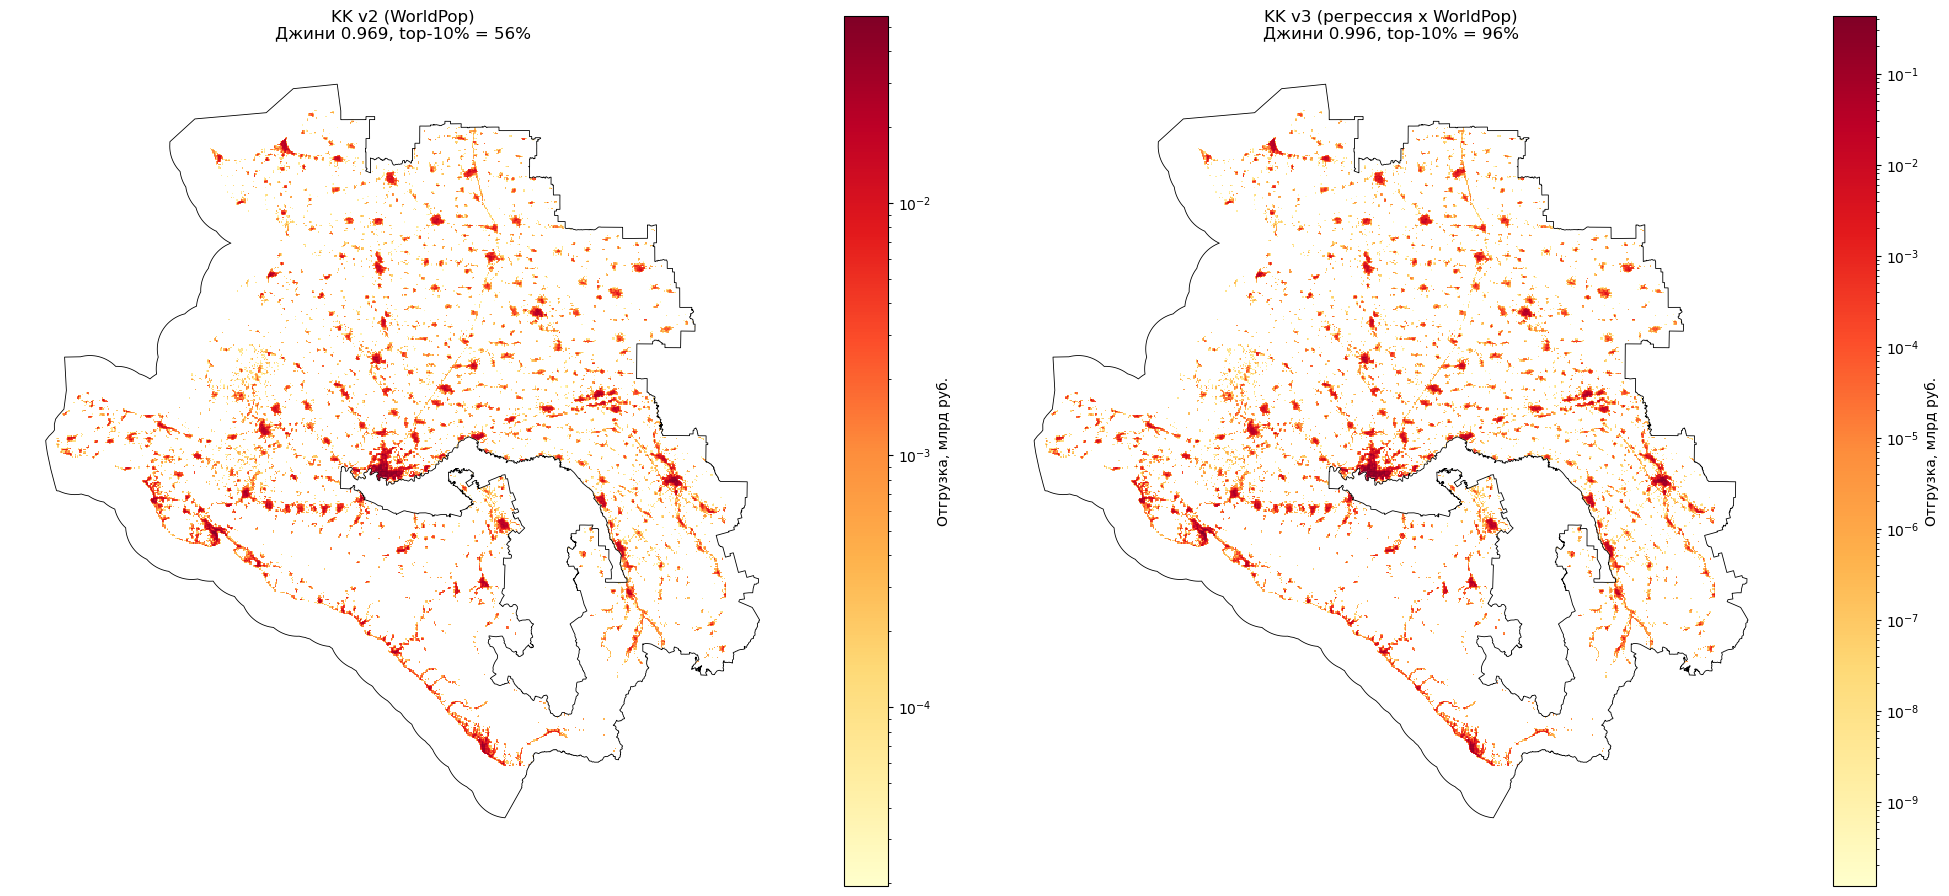

In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

g_v2 = grid_kk[grid_kk['method_otgr_v2'] > 0].copy()
g_v3 = grid_kk[grid_kk['method_otgr_v3'] > 0].copy()

g_v2.plot(column='method_otgr_v2', ax=axes[0], cmap='YlOrRd',
          legend=True, norm=mcolors.LogNorm(),
          legend_kwds={'label': 'Отгрузка, млрд руб.'})
kk.boundary.plot(ax=axes[0], color='black', linewidth=0.6)
axes[0].set_title(f'KK v2 (WorldPop)\nДжини {gini(grid_kk["method_otgr_v2"].values):.3f}, top-10% = {top_share(grid_kk["method_otgr_v2"].values)*100:.0f}%')
axes[0].set_axis_off()

g_v3.plot(column='method_otgr_v3', ax=axes[1], cmap='YlOrRd',
          legend=True, norm=mcolors.LogNorm(),
          legend_kwds={'label': 'Отгрузка, млрд руб.'})
kk.boundary.plot(ax=axes[1], color='black', linewidth=0.6)
axes[1].set_title(f'KK v3 (регрессия x WorldPop)\nДжини {gini(grid_kk["method_otgr_v3"].values):.3f}, top-10% = {top_share(grid_kk["method_otgr_v3"].values)*100:.0f}%')
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig('../results/kk_v2_vs_v3.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## Карта v3 для центральной Якутии
Бокс 400x400 км вокруг Якутска, сетка 1x1 км

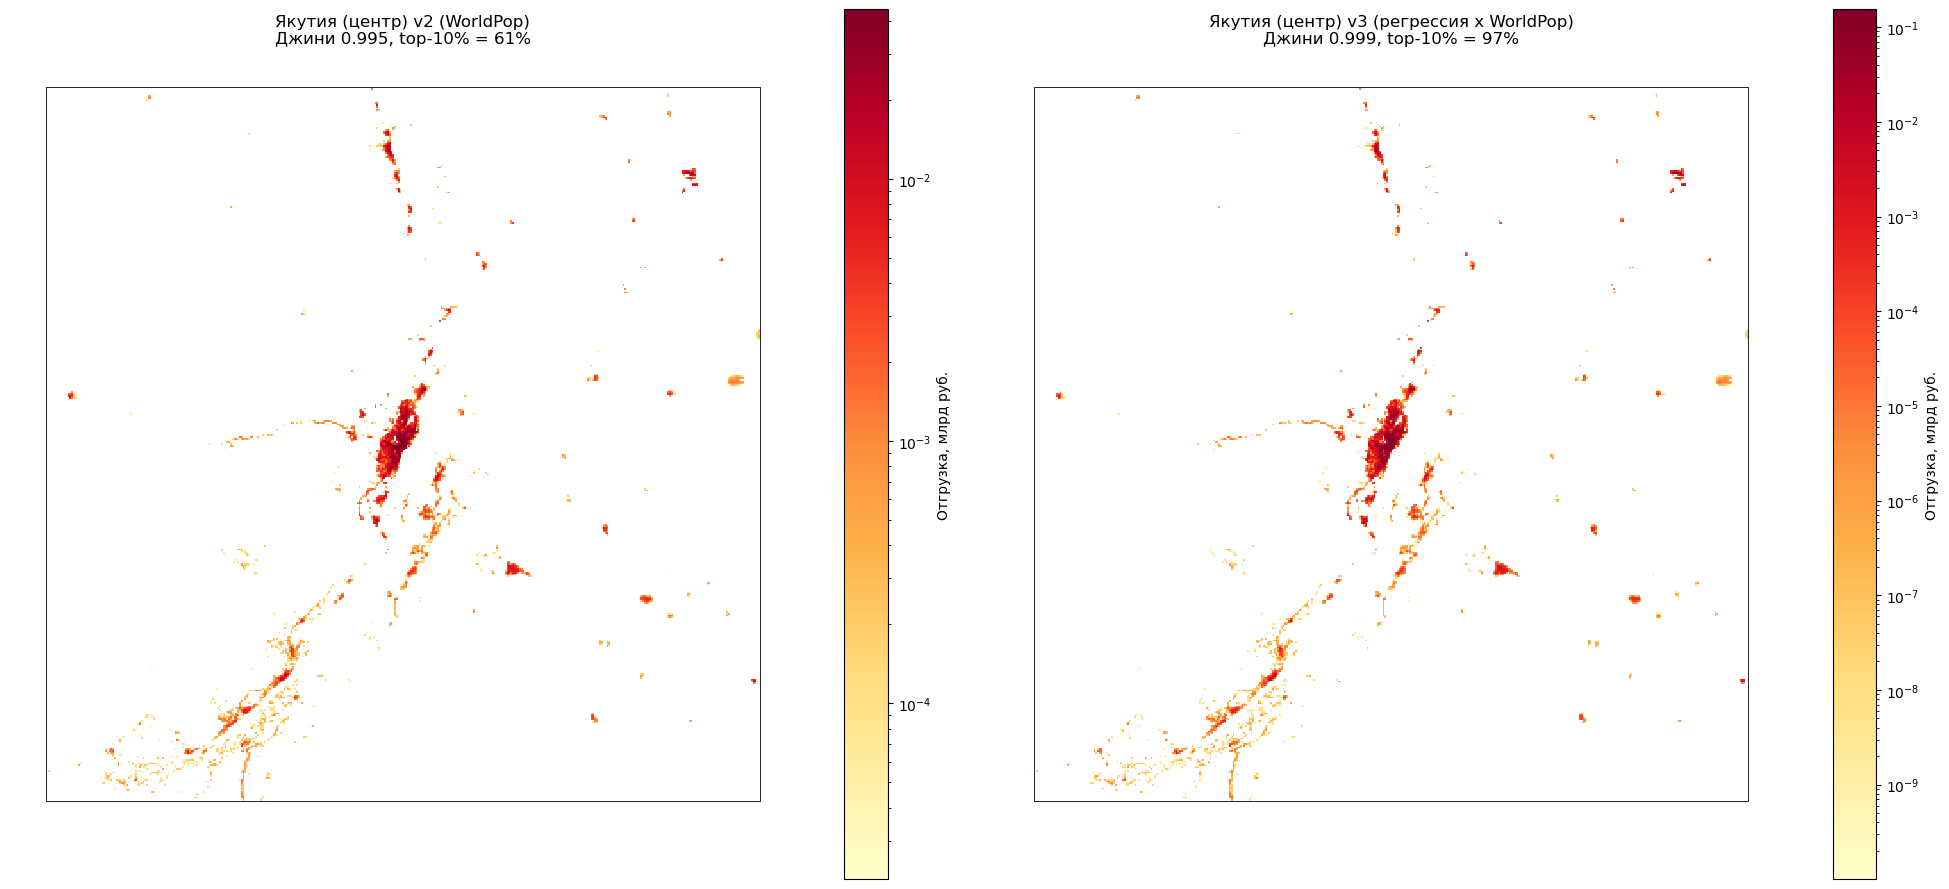

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

if 'method_otgr_v2' in grid_ya.columns:
    g_v2 = grid_ya[grid_ya['method_otgr_v2'] > 0].copy()
    g_v2.plot(column='method_otgr_v2', ax=axes[0], cmap='YlOrRd',
              legend=True, norm=mcolors.LogNorm(),
              legend_kwds={'label': 'Отгрузка, млрд руб.'})
    ya.boundary.plot(ax=axes[0], color='black', linewidth=0.6)
    axes[0].set_title(f'Якутия (центр) v2 (WorldPop)\nДжини {gini(grid_ya["method_otgr_v2"].values):.3f}, top-10% = {top_share(grid_ya["method_otgr_v2"].values)*100:.0f}%')
else:
    axes[0].text(0.5, 0.5, 'v2 не посчитан для grid_ya', ha='center', va='center')
axes[0].set_axis_off()

g_v3 = grid_ya[grid_ya['method_otgr_v3'] > 0].copy()
g_v3.plot(column='method_otgr_v3', ax=axes[1], cmap='YlOrRd',
          legend=True, norm=mcolors.LogNorm(),
          legend_kwds={'label': 'Отгрузка, млрд руб.'})
ya.boundary.plot(ax=axes[1], color='black', linewidth=0.6)
axes[1].set_title(f'Якутия (центр) v3 (регрессия x WorldPop)\nДжини {gini(grid_ya["method_otgr_v3"].values):.3f}, top-10% = {top_share(grid_ya["method_otgr_v3"].values)*100:.0f}%')
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig('../results/ya_v2_vs_v3.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## Сводная таблица: все методы x все регионы
Джини и top-10% по каждой паре

In [65]:
import pandas as pd

def summarize(grid, region_name):
    rows = []
    methods = [
        ('Baseline (равномерный)', 'baseline_otgr'),
        ('v1 (затухание по расстояниям)', 'method_otgr'),
        ('v2 (дасиметрия WorldPop)', 'method_otgr_v2'),
        ('v3 (регрессия x WorldPop)', 'method_otgr_v3'),
    ]
    for name, col in methods:
        if col in grid.columns:
            values = grid[col].fillna(0).values
            rows.append({
                'Регион': region_name,
                'Метод': name,
                'Джини': round(float(gini(values)), 3),
                'Top-10%': f"{top_share(values)*100:.1f}%",
                'Сумма': round(float(values.sum()), 2),
                'Ячеек': int((values > 0).sum()),
            })
    return rows

summary_rows = []
summary_rows += summarize(grid_mo, 'Московская область')
summary_rows += summarize(grid_kk, 'Краснодарский край')
summary_rows += summarize(grid_ya, 'Якутия (центр)')

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../results/summary_metrics.csv', index=False)
summary_df

,Регион,Метод,Джини,Top-10%,Сумма,Ячеек
0,Московская область,Baseline (равномерный),0.018,10.2%,209.0,141967
1,Московская область,v1 (затухание по расстояниям),0.349,29.5%,209.0,141967
2,Московская область,v2 (дасиметрия WorldPop),0.910,62.1%,209.0,48815
3,Московская область,v3 (регрессия x WorldPop),0.993,99.1%,209.0,48815
4,Краснодарский край,Baseline (равномерный),0.014,10.1%,59.7,185691
5,Краснодарский край,v1 (затухание по расстояниям),0.303,26.9%,59.7,185691
6,Краснодарский край,v2 (дасиметрия WorldPop),0.969,56.1%,59.7,20429
7,Краснодарский край,v3 (регрессия x WorldPop),0.996,96.4%,59.7,20429
8,Якутия (центр),Baseline (равномерный),0.005,10.1%,11.2,160801
9,Якутия (центр),v1 (затухание по расстояниям),0.331,29.7%,11.2,160801


In [66]:
pivot = summary_df.copy()
pivot['Значение'] = pivot.apply(lambda r: f"Джини {r['Джини']} / top-10% {r['Top-10%']}", axis=1)
pivot_table = pivot.pivot(index='Метод', columns='Регион', values='Значение')
pivot_table.to_csv('../results/summary_for_slide.csv')
pivot_table

Регион,Краснодарский край,Московская область,Якутия (центр)
Метод,,,
Baseline (равномерный),Джини 0.014 / top-10% 10.1%,Джини 0.018 / top-10% 10.2%,Джини 0.005 / top-10% 10.1%
v1 (затухание по расстояниям),Джини 0.303 / top-10% 26.9%,Джини 0.349 / top-10% 29.5%,Джини 0.331 / top-10% 29.7%
v2 (дасиметрия WorldPop),Джини 0.969 / top-10% 56.1%,Джини 0.91 / top-10% 62.1%,Джини 0.995 / top-10% 61.2%
v3 (регрессия x WorldPop),Джини 0.996 / top-10% 96.4%,Джини 0.993 / top-10% 99.1%,Джини 0.999 / top-10% 96.6%
